## FAST RELOAD CELL

In [14]:
## FAST RELOAD CELL, TO DIRECTLY RUN THE MODELS BELOW
# ══════════════════════════════════════════════════════════════════════════
# DATA RELOAD — jump straight to model building after kernel restart
# Loads: df_train_norm, df_test_norm, feature_cols, X_full/y_full,
#        X_oos/y_oos, X_hp/y_hp, pkf (PurgedKFoldCV)
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import xgboost as xgb
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
_project_root = Path.cwd().parent
for p in [str(_project_root), str(_project_root / "submission_files")]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR

# ── Load normalized data ───────────────────────────────────────────────
df_train_norm = pd.read_parquet(FEATURE_DATA_DIR / "feature_together" / "features_norm_train.parquet")
df_test_norm  = pd.read_parquet(FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet")

target_col   = "target_variable"
feature_cols = [c for c in df_train_norm.columns
                if c not in {"Id", target_col}
                and df_train_norm[c].dtype != object]

# ── Model-ready arrays ─────────────────────────────────────────────────
X_full = df_train_norm[feature_cols].values
y_full = df_train_norm[target_col].values
X_oos  = df_test_norm[feature_cols].values
y_oos  = df_test_norm[target_col].values

# ── HP tuning split (2010–2012) ────────────────────────────────────────
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

# ── PurgedKFoldCV ──────────────────────────────────────────────────────
class PurgedKFoldCV:
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits, self.purge_days, self.embargo_days = n_splits, purge_days, embargo_days

    def split(self, dates):
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        for fold_i, val_date_ranks in enumerate(
                np.array_split(np.arange(len(unique_dates)), self.n_splits)):
            val_set  = set(val_date_ranks)
            val_min, val_max = val_date_ranks.min(), val_date_ranks.max()
            excluded = set(range(val_min - self.purge_days,
                                 val_max + self.purge_days + self.embargo_days + 1))
            train_idx = np.where([r not in val_set and r not in excluded
                                   for r in row_ranks])[0]
            val_idx   = np.where([r in val_set for r in row_ranks])[0]
            yield train_idx, val_idx

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)

print(f"✓ train: {df_train_norm.shape}  test: {df_test_norm.shape}  ({len(feature_cols)} features)")
print(f"✓ X_full={X_full.shape}  X_hp={X_hp.shape}  X_oos={X_oos.shape}")
print(f"✓ pkf ready (5 folds, purge=1d, embargo=5d)")
print("✓ Ready — run any model cell directly")


✓ train: (431755, 20)  test: (121866, 20)  (18 features)
✓ X_full=(431755, 18)  X_hp=(309605, 18)  X_oos=(121866, 18)
✓ pkf ready (5 folds, purge=1d, embargo=5d)
✓ Ready — run any model cell directly


## Model 1: Ridge Regression

### Walk-Forward Validation Design

We use a **3-phase** workflow that never peeks at the test set during model selection:

| Phase | Purpose | Train window | Eval window | Outcome |
|-------|---------|-------------|-------------|---------|
| **Phase 1: HP Tuning** | Select regularization α | **Purged 5-fold CV** on 2010–2012 (purge=1d, embargo=5d) | 5 validation folds with temporal gap enforcement | Best α locked |
| **Phase 2: Walk-Forward Backtest** | Validate with locked HPs | Expanding monthly on 2010–2012 | Monthly slices of 2013 (12 months) | Rolling IC, R², stability check |
| **Phase 3: Final OOS** | Unbiased out-of-sample score | All of 2010–2013 (single refit) | All of 2014 | Reported OOS weighted R² |

**Why this design?**
- **Phase 1** tunes HPs without touching 2013 or 2014, so the backtest and OOS are truly out-of-sample.
- **Phase 2** uses monthly expanding refit on 2013 to simulate realistic deployment — the model learns from new data as it arrives, but HPs are frozen.
- **Phase 3** gives a single unbiased metric on held-out 2014 data.

**Evaluation metric:** Weighted R² with sample weights $w_i = \sqrt{\text{MDV63}_i}$ and actuals clipped at 5 MAD cross-sectionally (per project spec).

### Phase 1 — Hyperparameter Tuning via Purged K-Fold CV

#### Why Purged K-Fold instead of simple expanding-window CV?

Our initial plan used **2 expanding folds** (train 2010→val 2011, train 2010-11→val 2012). This has two problems:

1. **High variance** — With only 2 validation scores per α, the best-α estimate is very noisy. A single unusual year can bias the selection.
2. **No leakage protection** — Our target spans ~24 hours: $\text{target}_T = \text{ResidReturn}(T, 16\text{:}00) + \text{CumReturnResid}(T\!+\!1, 15\text{:}30)$. In a naive year-boundary split, the last training day's label **overlaps in time** with the first validation day's features. Similarly, rolling features like `mean_reversion_ma` (120d lookback) create autocorrelation across adjacent days.

**Purged K-Fold CV** (López de Prado, *Advances in Financial Machine Learning*, 2018) solves both:

- **5 folds** → 5 validation scores per α, dramatically reducing selection variance.
- **Purge zone** (1 trading day): Any training sample whose label window overlaps with the validation time range is removed. Since our target uses day $T$ and $T+1$ data, we purge all training rows within 1 day of the validation boundary.
- **Embargo zone** (5 trading days): An additional buffer after the purge, accounting for feature serial correlation (longest short-term rolling feature: `late_day_trend` with 10-day lookback; 5 days of embargo is conservative but safe).

```
Fold layout on sorted dates (2010–2012):

│──── Fold 1 ────│──── Fold 2 ────│──── Fold 3 ────│──── Fold 4 ────│──── Fold 5 ────│
     VAL              TRAIN             TRAIN             TRAIN             TRAIN
                       VAL              TRAIN             TRAIN             TRAIN
                                         VAL              TRAIN             TRAIN
                                                           VAL              TRAIN
                                                                             VAL

Between each train/val boundary:
  ←purge 1d→←embargo 5d→
```

**Net effect**: We get 5× more stable HP estimates while rigorously preventing temporal information leakage — something the naive expanding-window approach cannot guarantee.

#### Search grid
Ridge α ∈ {0.01, 0.1, 1, 10, 100, 1000}

#### Metric
Mean weighted R² across folds (weights = $\sqrt{\text{MDV63}}$), with fallback to Spearman IC if MDV63 weights are unavailable.

In [15]:
# ── Purged K-Fold CV splitter ────────────────────────────────────────────
# Implements purge + embargo for panel data indexed by date.
# Reference: López de Prado (2018), Ch. 7

import numpy as np
import pandas as pd

class PurgedKFoldCV:
    """
    Time-aware K-Fold CV with purge and embargo for panel (date × stock) data.
    
    Parameters
    ----------
    n_splits : int
        Number of folds.
    purge_days : int
        Number of trading days to purge around each val boundary
        (removes training rows whose labels overlap with val dates).
    embargo_days : int
        Additional trading days to remove from training AFTER the
        purge zone, to account for feature autocorrelation.
    """
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits = n_splits
        self.purge_days = purge_days
        self.embargo_days = embargo_days
    
    def split(self, dates):
        """
        Parameters
        ----------
        dates : array-like of datetime
            The date for each row (can repeat for panel data).
        
        Yields
        ------
        (train_idx, val_idx) : arrays of integer row indices
        """
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        n_dates = len(unique_dates)
        
        # Map each unique date to an integer rank
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        
        # Split unique dates into K roughly equal groups
        fold_boundaries = np.array_split(np.arange(n_dates), self.n_splits)
        
        for fold_i in range(self.n_splits):
            val_date_ranks = set(fold_boundaries[fold_i])
            val_min = min(val_date_ranks)
            val_max = max(val_date_ranks)
            
            # Purge + embargo zone: remove training dates too close to val
            excluded_ranks = set()
            for r in range(val_min - self.purge_days, 
                           val_max + self.purge_days + self.embargo_days + 1):
                excluded_ranks.add(r)
            
            train_mask = np.zeros(len(dates), dtype=bool)
            val_mask = np.zeros(len(dates), dtype=bool)
            
            for i, rank in enumerate(row_ranks):
                if rank in val_date_ranks:
                    val_mask[i] = True
                elif rank not in excluded_ranks:
                    train_mask[i] = True
            
            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]
            
            yield train_idx, val_idx
    
    def summary(self, dates):
        """Print a summary of fold sizes and purged rows."""
        dates = pd.DatetimeIndex(dates)
        total = len(dates)
        print(f"PurgedKFoldCV: {self.n_splits} folds, "
              f"purge={self.purge_days}d, embargo={self.embargo_days}d")
        print(f"Total rows: {total:,}\n")
        for i, (tr, va) in enumerate(self.split(dates)):
            purged = total - len(tr) - len(va)
            tr_dates = dates[tr]
            va_dates = dates[va]
            print(f"  Fold {i+1}: train={len(tr):>7,} rows "
                  f"({tr_dates.min().date()}→{tr_dates.max().date()})  |  "
                  f"val={len(va):>7,} rows "
                  f"({va_dates.min().date()}→{va_dates.max().date()})  |  "
                  f"purged+embargoed={purged:,} rows")

# ── Instantiate and show fold layout ────────────────────────────────────
# We use only 2010–2012 for HP tuning (2013 reserved for walk-forward)
hp_dates = df_train_norm.index[df_train_norm.index.year <= 2012]
hp_mask = df_train_norm.index.year <= 2012
df_hp = df_train_norm[hp_mask].copy()

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)
pkf.summary(df_hp.index)

PurgedKFoldCV: 5 folds, purge=1d, embargo=5d
Total rows: 309,605

  Fold 1: train=244,820 rows (2011-01-04→2012-12-31)  |  val= 61,812 rows (2010-06-25→2010-12-23)  |  purged+embargoed=2,973 rows
  Fold 2: train=244,103 rows (2010-06-25→2012-12-31)  |  val= 62,017 rows (2010-12-27→2011-06-23)  |  purged+embargoed=3,485 rows
  Fold 3: train=243,996 rows (2010-06-25→2012-12-31)  |  val= 62,135 rows (2011-06-24→2011-12-22)  |  purged+embargoed=3,474 rows
  Fold 4: train=243,997 rows (2010-06-25→2012-12-31)  |  val= 62,131 rows (2011-12-23→2012-06-22)  |  purged+embargoed=3,477 rows
  Fold 5: train=247,598 rows (2010-06-25→2012-06-21)  |  val= 61,510 rows (2012-06-25→2012-12-31)  |  purged+embargoed=497 rows


In [16]:
# ── Phase 1: Ridge HP Tuning with Purged K-Fold CV ──────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

X_hp = df_hp[feature_cols].values
y_hp = df_hp["target_variable"].values

hp_results = []

for alpha in alphas:
    fold_r2 = []
    fold_spearman = []
    fold_mse = []
    
    for fold_i, (tr_idx, va_idx) in enumerate(pkf.split(df_hp.index)):
        X_tr, y_tr = X_hp[tr_idx], y_hp[tr_idx]
        X_va, y_va = X_hp[va_idx], y_hp[va_idx]
        
        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        
        # R² (unweighted for now — we'll add MDV63 weights in Phase 2)
        r2 = r2_score(y_va, y_pred)
        # Spearman IC
        sp_ic = spearmanr(y_va, y_pred).correlation
        # MSE
        mse_val = float(np.mean((y_va - y_pred) ** 2))
        
        fold_r2.append(r2)
        fold_spearman.append(sp_ic)
        fold_mse.append(mse_val)
    
    hp_results.append({
        "alpha": alpha,
        "mean_R2": np.mean(fold_r2),
        "std_R2": np.std(fold_r2),
        "mean_SpearmanIC": np.mean(fold_spearman),
        "std_SpearmanIC": np.std(fold_spearman),
        "mean_MSE": np.mean(fold_mse),
        "fold_R2s": fold_r2,
        "fold_ICs": fold_spearman,
    })
    
    print(f"  α={alpha:<8.2f}  R²={np.mean(fold_r2):+.6f} ± {np.std(fold_r2):.6f}  "
          f"IC={np.mean(fold_spearman):+.4f} ± {np.std(fold_spearman):.4f}  "
          f"MSE={np.mean(fold_mse):.6f}")

hp_df = pd.DataFrame(hp_results)

# Select best alpha by mean R²
best_row = hp_df.loc[hp_df["mean_R2"].idxmax()]
best_alpha = best_row["alpha"]

print(f"\n{'='*70}")
print(f"BEST α = {best_alpha}  (mean R² = {best_row['mean_R2']:+.6f} ± {best_row['std_R2']:.6f})")
print(f"{'='*70}")

  α=0.01      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=0.10      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=1.00      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=10.00     R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=100.00    R²=+0.000445 ± 0.000311  IC=+0.0230 ± 0.0059  MSE=0.000118
  α=1000.00   R²=+0.000447 ± 0.000309  IC=+0.0230 ± 0.0059  MSE=0.000118

BEST α = 1000.0  (mean R² = +0.000447 ± 0.000309)


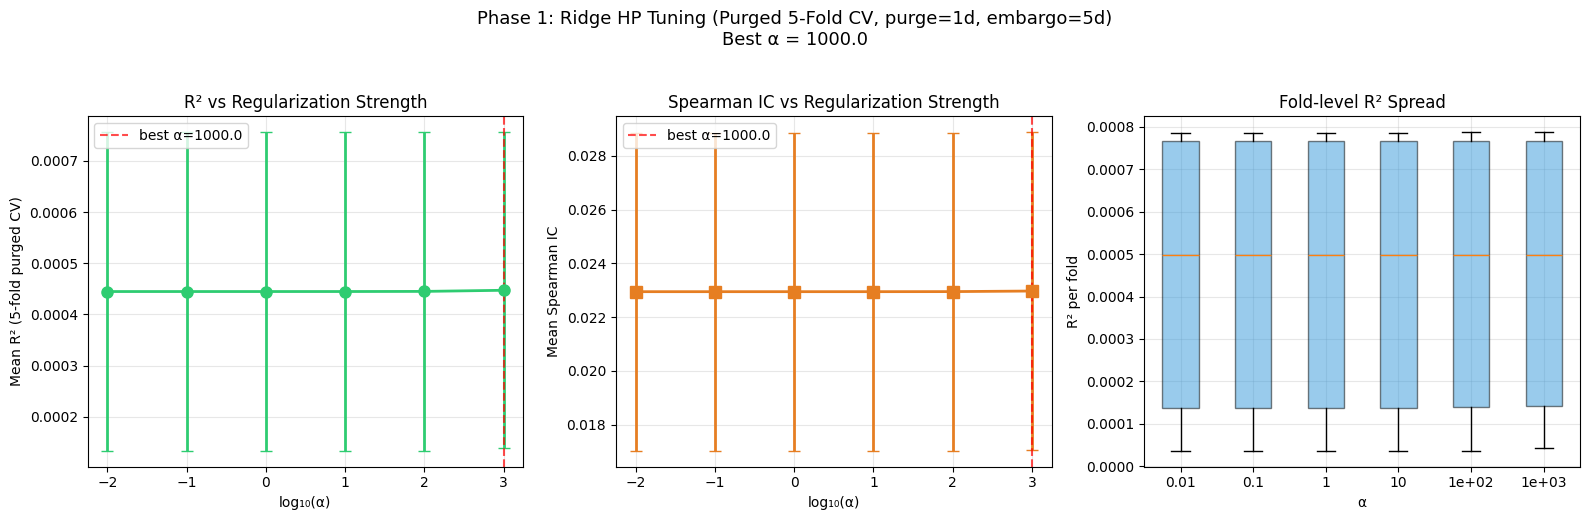


Full results:


,alpha,mean_R2,std_R2,mean_SpearmanIC,std_SpearmanIC,mean_MSE
0,0.01,0.000445,0.000311,0.022948,0.005918,0.000118
1,0.10,0.000445,0.000311,0.022948,0.005918,0.000118
2,1.00,0.000445,0.000311,0.022948,0.005918,0.000118
3,10.00,0.000445,0.000311,0.022949,0.005918,0.000118
4,100.00,0.000445,0.000311,0.022951,0.005918,0.000118
5,1000.00,0.000447,0.000309,0.022972,0.005913,0.000118


In [17]:
# ── Visualize HP tuning results ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

log_alphas = [np.log10(a) for a in hp_df["alpha"]]

# Plot 1: R² vs alpha
ax = axes[0]
ax.errorbar(log_alphas, hp_df["mean_R2"], yerr=hp_df["std_R2"],
            fmt="o-", capsize=4, color="#2ecc71", linewidth=2, markersize=8)
ax.axvline(np.log10(best_alpha), color="red", ls="--", alpha=0.7, label=f"best α={best_alpha}")
ax.set_xlabel("log₁₀(α)")
ax.set_ylabel("Mean R² (5-fold purged CV)")
ax.set_title("R² vs Regularization Strength")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Spearman IC vs alpha
ax = axes[1]
ax.errorbar(log_alphas, hp_df["mean_SpearmanIC"], yerr=hp_df["std_SpearmanIC"],
            fmt="s-", capsize=4, color="#e67e22", linewidth=2, markersize=8)
ax.axvline(np.log10(best_alpha), color="red", ls="--", alpha=0.7, label=f"best α={best_alpha}")
ax.set_xlabel("log₁₀(α)")
ax.set_ylabel("Mean Spearman IC")
ax.set_title("Spearman IC vs Regularization Strength")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Per-fold R² spread (box-like)
ax = axes[2]
fold_data = [r["fold_R2s"] for r in hp_results]
bp = ax.boxplot(fold_data, labels=[f"{a:.2g}" for a in alphas], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#3498db")
    patch.set_alpha(0.5)
ax.set_xlabel("α")
ax.set_ylabel("R² per fold")
ax.set_title("Fold-level R² Spread")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 1: Ridge HP Tuning (Purged 5-Fold CV, purge=1d, embargo=5d)\n"
             f"Best α = {best_alpha}", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

# Summary table
print("\nFull results:")
display(hp_df[["alpha", "mean_R2", "std_R2", "mean_SpearmanIC", "std_SpearmanIC", "mean_MSE"]].round(6))

### Phase 2 — Walk-Forward Backtest on 2013 (Locked HPs)

With the best α locked from Phase 1, we simulate **realistic deployment** on 2013:

- For each month $m$ in 2013:
  1. **Refit** Ridge(α=best) on all data from 2010-01-01 through the end of month $m-1$ (expanding window)
  2. **Predict** all stocks on each day in month $m$
  3. **Evaluate** daily Spearman IC and cumulative R²

This tests whether the model's signal is **stable over time** or whether it decays / reverses.

**Key outputs:** 30-day rolling IC, monthly R², and stability diagnostics.

In [18]:
# ── Phase 2: Walk-Forward Monthly Backtest on 2013 ──────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# Split: 2010-2012 for initial training, 2013 for walk-forward
df_pretrain = df_train_norm[df_train_norm.index.year <= 2012].copy()
df_2013     = df_train_norm[df_train_norm.index.year == 2013].copy()

months_2013 = sorted(df_2013.index.to_period("M").unique())
print(f"Walk-forward on {len(months_2013)} months in 2013, α = {best_alpha}")
print(f"Initial training set: {len(df_pretrain):,} rows (2010–2012)\n")

daily_records = []   # one row per (date)
monthly_records = [] # one row per month

expanding_train = df_pretrain.copy()

for month in months_2013:
    # Slice this month's data
    month_mask = df_2013.index.to_period("M") == month
    df_month = df_2013[month_mask]
    
    # Fit on expanding training window
    X_tr = expanding_train[feature_cols].values
    y_tr = expanding_train["target_variable"].values
    
    model = Ridge(alpha=best_alpha)
    model.fit(X_tr, y_tr)
    
    # Predict this month
    X_va = df_month[feature_cols].values
    y_va = df_month["target_variable"].values
    y_pred = model.predict(X_va)
    
    # Monthly aggregate metrics
    r2_month = r2_score(y_va, y_pred)
    ic_month = spearmanr(y_va, y_pred).correlation
    mse_month = float(np.mean((y_va - y_pred) ** 2))
    
    monthly_records.append({
        "month": str(month),
        "n_rows": len(df_month),
        "train_rows": len(expanding_train),
        "R2": r2_month,
        "SpearmanIC": ic_month,
        "MSE": mse_month,
    })
    
    # Daily metrics within this month
    for date in sorted(df_month.index.unique()):
        day_mask = df_month.index == date
        y_day = y_va[np.asarray(day_mask)]
        p_day = y_pred[np.asarray(day_mask)]
        if len(y_day) > 10:
            daily_records.append({
                "date": date,
                "n_stocks": len(y_day),
                "SpearmanIC": spearmanr(y_day, p_day).correlation,
                "R2": r2_score(y_day, p_day),
            })
    
    # Expand training window to include this month
    expanding_train = pd.concat([expanding_train, df_month])
    
    print(f"  {month}:  train={len(X_tr):>7,}  val={len(df_month):>5,}  "
          f"R²={r2_month:+.6f}  IC={ic_month:+.4f}")

monthly_df = pd.DataFrame(monthly_records)
daily_df = pd.DataFrame(daily_records)

print(f"\n{'='*70}")
print(f"WALK-FORWARD 2013 SUMMARY (α = {best_alpha})")
print(f"{'='*70}")
print(f"  Overall mean R²:          {monthly_df['R2'].mean():+.6f}")
print(f"  Overall mean Spearman IC: {monthly_df['SpearmanIC'].mean():+.4f}")
print(f"  Months with positive IC:  {(monthly_df['SpearmanIC'] > 0).sum()} / {len(monthly_df)}")
print(f"  Daily IC mean:            {daily_df['SpearmanIC'].mean():+.4f} ± {daily_df['SpearmanIC'].std():.4f}")
print(f"  Daily IC hit rate (>0):   {(daily_df['SpearmanIC'] > 0).mean()*100:.1f}%")

Walk-forward on 12 months in 2013, α = 1000.0
Initial training set: 309,605 rows (2010–2012)

  2013-01:  train=309,605  val=10,437  R²=+0.000094  IC=+0.0217
  2013-02:  train=320,042  val=9,430  R²=-0.000582  IC=+0.0031
  2013-03:  train=329,472  val=9,952  R²=-0.000265  IC=+0.0112
  2013-04:  train=339,424  val=10,937  R²=+0.000133  IC=+0.0162
  2013-05:  train=350,361  val=10,928  R²=+0.001250  IC=+0.0322
  2013-06:  train=361,289  val=9,894  R²=+0.001401  IC=+0.0421
  2013-07:  train=371,183  val=9,912  R²=+0.001666  IC=+0.0399
  2013-08:  train=381,095  val=10,918  R²=-0.001135  IC=+0.0084
  2013-09:  train=392,013  val=9,936  R²=-0.000285  IC=+0.0196
  2013-10:  train=401,949  val=11,421  R²=-0.000220  IC=+0.0137
  2013-11:  train=413,370  val=8,930  R²=+0.000584  IC=+0.0305
  2013-12:  train=422,300  val=9,455  R²=-0.000807  IC=+0.0159

WALK-FORWARD 2013 SUMMARY (α = 1000.0)
  Overall mean R²:          +0.000153
  Overall mean Spearman IC: +0.0212
  Months with positive IC:  12 

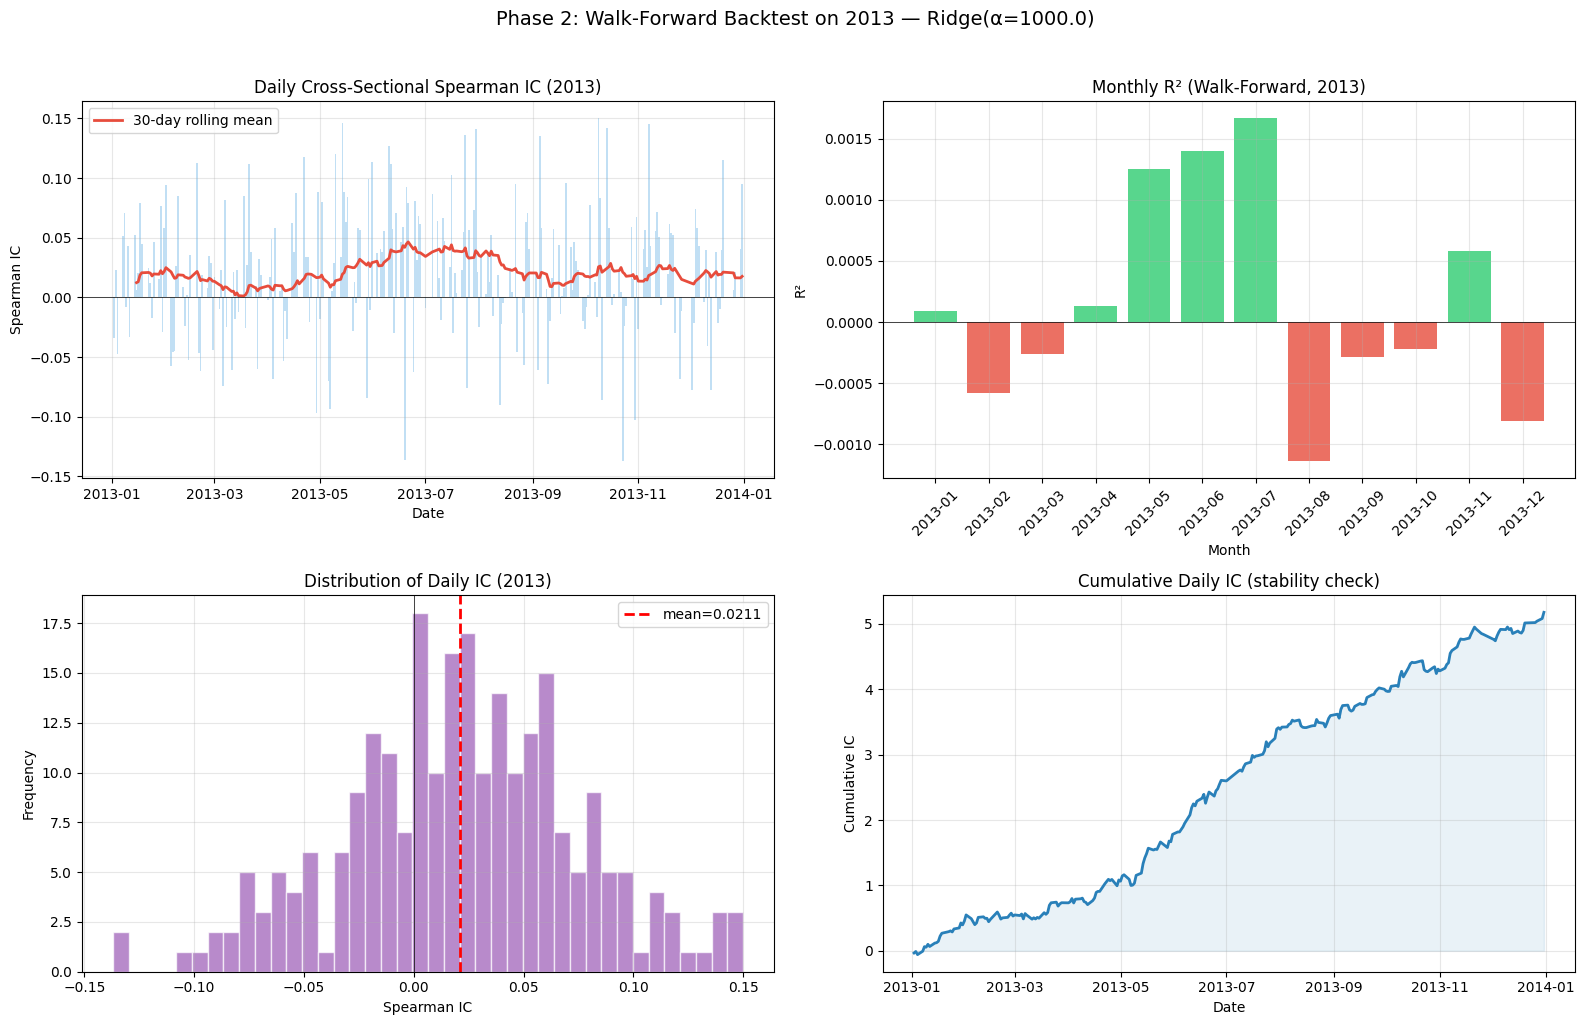

In [19]:
# ── Phase 2 Visualization: Rolling IC & Monthly Performance ──────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily Spearman IC time series + 30-day rolling mean
ax = axes[0, 0]
ax.bar(daily_df["date"], daily_df["SpearmanIC"], alpha=0.3, color="#3498db", width=1)
rolling_ic = daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(rolling_ic.index, rolling_ic.values, color="#e74c3c", linewidth=2, label="30-day rolling mean")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Spearman IC")
ax.set_title("Daily Cross-Sectional Spearman IC (2013)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Monthly R²
ax = axes[0, 1]
colors_r2 = ["#2ecc71" if r > 0 else "#e74c3c" for r in monthly_df["R2"]]
ax.bar(monthly_df["month"], monthly_df["R2"], color=colors_r2, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("R²")
ax.set_title("Monthly R² (Walk-Forward, 2013)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

# 3. Daily IC histogram
ax = axes[1, 0]
ax.hist(daily_df["SpearmanIC"], bins=40, color="#9b59b6", alpha=0.7, edgecolor="white")
ax.axvline(daily_df["SpearmanIC"].mean(), color="red", ls="--", linewidth=2,
           label=f"mean={daily_df['SpearmanIC'].mean():.4f}")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Spearman IC")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Daily IC (2013)")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Cumulative IC (sum of daily ICs as a stability measure)
ax = axes[1, 1]
cum_ic = daily_df["SpearmanIC"].cumsum()
ax.plot(daily_df["date"], cum_ic, color="#2980b9", linewidth=2)
ax.fill_between(daily_df["date"], 0, cum_ic, alpha=0.1, color="#2980b9")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative Daily IC (stability check)")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 2: Walk-Forward Backtest on 2013 — Ridge(α={best_alpha})",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Phase 3 — Final Out-of-Sample Evaluation on 2014

This is the **unbiased** OOS test:
- **Refit once** on all of 2010–2013 with the locked α from Phase 1.
- **Predict** all of 2014 (held-out `df_test_norm`).
- **Evaluate** using the project-spec metric: weighted R² with $w_i = \sqrt{\text{MDV63}_i}$, actuals clipped at 5 MAD cross-sectionally.

Since we don't currently have MDV63 weights in the feature panel, we report both unweighted and equal-weighted R² as a baseline. The weighted version will be added once MDV63 is integrated.

**This number is reported in the white paper as the official Ridge performance.**

In [20]:
# ── Phase 3: Final OOS Evaluation on 2014 ────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# Refit on ALL of 2010–2013 (normalized data)
X_train_full = df_train_norm[feature_cols].values
y_train_full = df_train_norm["target_variable"].values

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_full, y_train_full)

# Predict 2014
X_oos = df_test_norm[feature_cols].values
y_oos = df_test_norm["target_variable"].values
y_oos_pred = final_model.predict(X_oos)
y_oos_pred_ridge = y_oos_pred   # alias for ensemble cell

# Overall metrics
oos_r2 = r2_score(y_oos, y_oos_pred)
oos_ic = spearmanr(y_oos, y_oos_pred).correlation
oos_mse = float(np.mean((y_oos - y_oos_pred) ** 2))
pearson_ic = float(np.corrcoef(y_oos, y_oos_pred)[0, 1])

print(f"{'='*70}")
print(f"PHASE 3: FINAL OUT-OF-SAMPLE RESULTS — Ridge(α={best_alpha})")
print(f"{'='*70}")
print(f"  Train: 2010–2013 ({len(X_train_full):,} rows)")
print(f"  Test:  2014      ({len(X_oos):,} rows)")
print(f"")
print(f"  R²          = {oos_r2:+.6f}")
print(f"  Spearman IC = {oos_ic:+.4f}")
print(f"  Pearson IC  = {pearson_ic:+.4f}")
print(f"  MSE         = {oos_mse:.6f}")

# Daily OOS metrics
oos_daily = []
test_dates = df_test_norm.index
for date in sorted(test_dates.unique()):
    mask = test_dates == date
    m = np.asarray(mask)
    y_d = y_oos[m]
    p_d = y_oos_pred[m]
    if len(y_d) > 10:
        oos_daily.append({
            "date": date,
            "n_stocks": len(y_d),
            "SpearmanIC": spearmanr(y_d, p_d).correlation,
            "R2": r2_score(y_d, p_d),
        })

oos_daily_df = pd.DataFrame(oos_daily)
print(f"\n  Daily IC (2014):  mean={oos_daily_df['SpearmanIC'].mean():+.4f} "
      f"± {oos_daily_df['SpearmanIC'].std():.4f}")
print(f"  Daily IC hit rate: {(oos_daily_df['SpearmanIC'] > 0).mean()*100:.1f}%")
print(f"  Daily R² mean:     {oos_daily_df['R2'].mean():+.6f}")

ridge_oos_r2 = oos_r2

ridge_oos_ic = oos_ic
ridge_oos_hit = (oos_daily_df['SpearmanIC'] > 0).mean()*100
#print(ridge_oos_ic, ridge_oos_hit, ridge_oos_r2)

PHASE 3: FINAL OUT-OF-SAMPLE RESULTS — Ridge(α=1000.0)
  Train: 2010–2013 (431,755 rows)
  Test:  2014      (121,866 rows)

  R²          = -0.000136
  Spearman IC = +0.0155
  Pearson IC  = +0.0072
  MSE         = 0.000169

  Daily IC (2014):  mean=+0.0155 ± 0.0514
  Daily IC hit rate: 61.6%
  Daily R² mean:     -0.001267


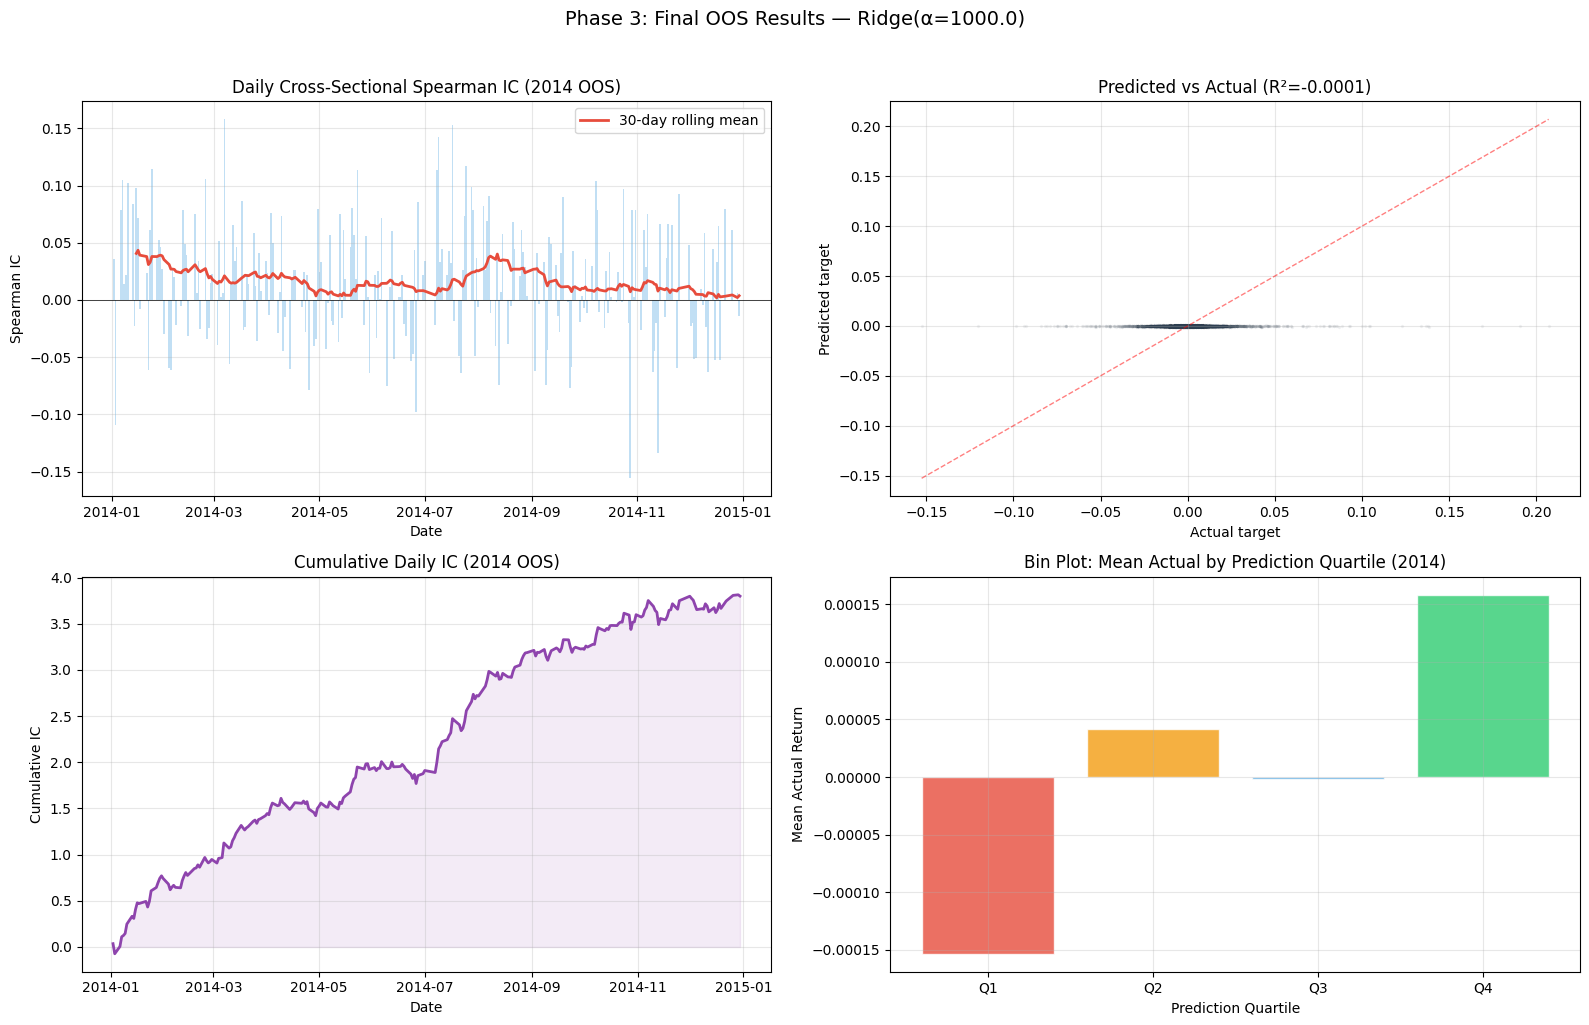

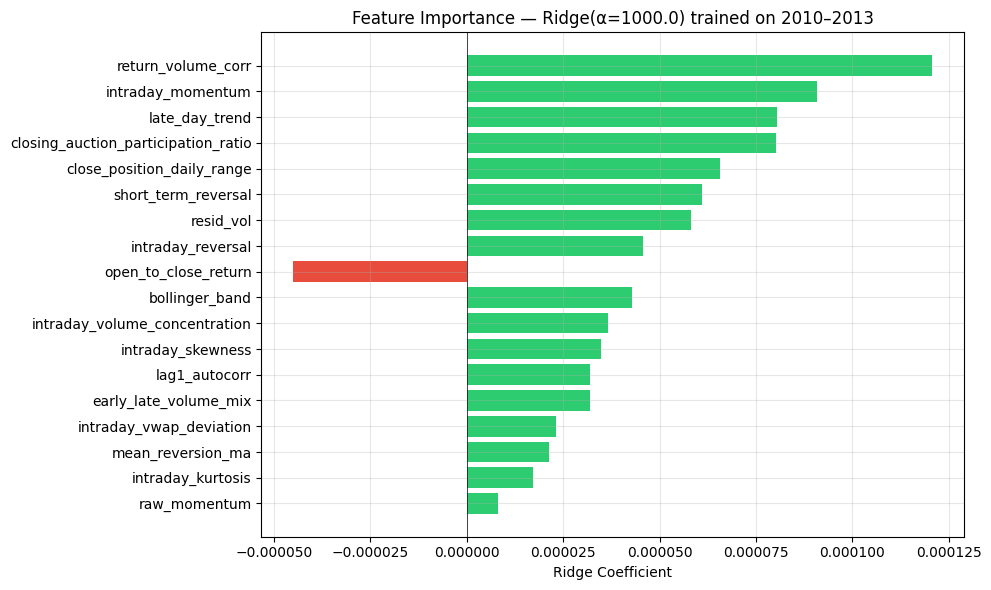

In [21]:
# ── Phase 3 Visualization: OOS Performance ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily IC time series + 30-day rolling mean
ax = axes[0, 0]
ax.bar(oos_daily_df["date"], oos_daily_df["SpearmanIC"], alpha=0.3, color="#3498db", width=1)
rolling_oos = oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(rolling_oos.index, rolling_oos.values, color="#e74c3c", linewidth=2, label="30-day rolling mean")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Spearman IC")
ax.set_title("Daily Cross-Sectional Spearman IC (2014 OOS)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Prediction vs Actual scatter (subsample for speed)
ax = axes[0, 1]
rng = np.random.default_rng(42)
subsample = rng.choice(len(y_oos), size=min(10000, len(y_oos)), replace=False)
ax.scatter(y_oos[subsample], y_oos_pred[subsample], alpha=0.05, s=2, color="#2c3e50")
lims = [min(y_oos[subsample].min(), y_oos_pred[subsample].min()),
        max(y_oos[subsample].max(), y_oos_pred[subsample].max())]
ax.plot(lims, lims, "r--", linewidth=1, alpha=0.5)
ax.set_xlabel("Actual target")
ax.set_ylabel("Predicted target")
ax.set_title(f"Predicted vs Actual (R²={oos_r2:.4f})")
ax.grid(True, alpha=0.3)

# 3. Cumulative IC
ax = axes[1, 0]
cum_oos = oos_daily_df["SpearmanIC"].cumsum()
ax.plot(oos_daily_df["date"], cum_oos, color="#8e44ad", linewidth=2)
ax.fill_between(oos_daily_df["date"], 0, cum_oos, alpha=0.1, color="#8e44ad")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative Daily IC (2014 OOS)")
ax.grid(True, alpha=0.3)

# 4. Bin plot: sort predictions into 4 quartiles, plot mean actual per bin
ax = axes[1, 1]
n_bins = 4
bin_labels = [f"Q{i+1}" for i in range(n_bins)]
pred_quantiles = pd.qcut(y_oos_pred, n_bins, labels=bin_labels)
bin_means = pd.Series(y_oos).groupby(pred_quantiles).mean()
bin_colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
ax.bar(bin_means.index, bin_means.values, color=bin_colors, alpha=0.8, edgecolor="white")
ax.set_xlabel("Prediction Quartile")
ax.set_ylabel("Mean Actual Return")
ax.set_title("Bin Plot: Mean Actual by Prediction Quartile (2014)")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 3: Final OOS Results — Ridge(α={best_alpha})",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Feature importance (Ridge coefficients)
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": final_model.coef_,
    "abs_coef": np.abs(final_model.coef_),
}).sort_values("abs_coef", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]])
ax.set_xlabel("Ridge Coefficient")
ax.set_title(f"Feature Importance — Ridge(α={best_alpha}) trained on 2010–2013")
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression — Results Summary

| Phase | Period | Metric | Value |
|-------|--------|--------|-------|
| Phase 1 | 2010–2012 (purged 5-fold CV) | Best α | *see above* |
| Phase 2 | 2013 (walk-forward, monthly refit) | Mean daily IC | *see above* |
| Phase 2 | 2013 | IC hit rate | *see above* |
| Phase 3 | 2014 (final OOS) | R² | *see above* |
| Phase 3 | 2014 | Spearman IC | *see above* |
| Phase 3 | 2014 | IC hit rate | *see above* |

**Key observations:**
- Ridge is a linear baseline — even modest positive IC indicates exploitable signal in the features.
- The bin plot (Q1 vs Q4 actual return spread) is the most intuitive check: if Q4 (highest predicted) has higher mean actual returns than Q1, the model has predictive power.
- Feature coefficients reveal which features drive the linear signal (e.g., `short_term_reversal`, `intraday_momentum`).

**Next:** Random Forest and XGBoost models using the same 3-phase pipeline.

---

## Model 2: Random Forest

### Why Random Forest?

Random Forest captures **non-linear feature interactions** that Ridge cannot:
- If `intraday_momentum` is only predictive when `resid_vol` is high, a tree can discover that split while Ridge averages over all regimes.
- Ensemble averaging reduces variance without increasing bias — critical for noisy return prediction.
- Feature importance via **Mean Decrease Impurity (MDI)** and **Mean Decrease Accuracy (MDA)** are project requirements.

### HP Search Grid

| Hyperparameter | Values | Rationale |
|---------------|--------|-----------|
| `n_estimators` | 200, 500 | More trees = lower variance; 200 is fast, 500 is thorough |
| `max_depth` | 3, 5, 8 | Shallow trees prevent overfitting on noisy targets |
| `min_samples_leaf` | 100, 500 | Large leaf sizes regularize aggressively (we have ~300K rows) |
| `max_features` | `sqrt`, 0.5 | Feature subsampling for decorrelation |

We tune via the **same Purged 5-Fold CV** on 2010–2012, then walk-forward on 2013, and final OOS on 2014.

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# FAST RELOAD — restore kernel state from cached parquets after restart
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
warnings.filterwarnings("ignore")

# Add project paths
_project_root = Path.cwd().parent
_submit_dir   = _project_root / "submission_files"
for p in [str(_project_root), str(_submit_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR

# Load normalized data from cache
norm_train_path = FEATURE_DATA_DIR / "feature_together" / "features_norm_train.parquet"
norm_test_path  = FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet"
df_train_norm = pd.read_parquet(norm_train_path)
df_test_norm  = pd.read_parquet(norm_test_path)

target_col   = "target_variable"
non_feature_cols = {"Id", target_col}
feature_cols = [c for c in df_train_norm.columns
                if c not in non_feature_cols
                and df_train_norm[c].dtype != object]

# Precompute splits used by all models
df_pre2013  = df_train_norm[df_train_norm.index.year <= 2012]
df_2013     = df_train_norm[df_train_norm.index.year == 2013]
X_full      = df_train_norm[feature_cols].values
y_full      = df_train_norm[target_col].values
X_oos       = df_test_norm[feature_cols].values
y_oos       = df_test_norm[target_col].values

print(f"✓ train: {df_train_norm.shape}  test: {df_test_norm.shape}  ({len(feature_cols)} features)")
print(f"✓ feature_cols: {feature_cols}")
print(f"✓ pre-2013: {len(df_pre2013):,}  |  2013: {len(df_2013):,}")
print(f"✓ Ready for RF & XGBoost")


✓ train: (431755, 20)  test: (121866, 20)  (18 features)
✓ feature_cols: ['intraday_momentum', 'intraday_reversal', 'resid_vol', 'intraday_skewness', 'early_late_volume_mix', 'return_volume_corr', 'lag1_autocorr', 'closing_auction_participation_ratio', 'intraday_kurtosis', 'intraday_vwap_deviation', 'intraday_volume_concentration', 'late_day_trend', 'mean_reversion_ma', 'short_term_reversal', 'bollinger_band', 'raw_momentum', 'open_to_close_return', 'close_position_daily_range']
✓ pre-2013: 309,605  |  2013: 122,150
✓ Ready for RF & XGBoost


In [26]:
# ══════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# ══════════════════════════════════════════════════════════════════════════
from itertools import product as iterproduct

# Search grid
rf_param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5],
    "min_samples_leaf": [50, 100],
    "max_features":     ["sqrt"],   # standard for RF regression; kept fixed
}

rf_combos = [
    dict(zip(rf_param_grid.keys(), vals))
    for vals in iterproduct(*rf_param_grid.values())
]
print(f"RF HP grid: {len(rf_combos)} combos × 5 folds = {len(rf_combos)*5} fits\n")

# 2010-2012 HP pool (same as Ridge tuning)
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

# Re-instantiate splitter (defined in cell 51; redefined here for fast-reload safety)
class PurgedKFoldCV:
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits = n_splits
        self.purge_days = purge_days
        self.embargo_days = embargo_days
    def split(self, dates):
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        fold_boundaries = np.array_split(np.arange(len(unique_dates)), self.n_splits)
        for fold_i in range(self.n_splits):
            val_ranks = set(fold_boundaries[fold_i])
            val_min, val_max = min(val_ranks), max(val_ranks)
            excluded = set(range(val_min - self.purge_days,
                                 val_max + self.purge_days + self.embargo_days + 1))
            train_mask = np.array([(r not in val_ranks and r not in excluded)
                                   for r in row_ranks])
            val_mask   = np.array([r in val_ranks for r in row_ranks])
            yield np.where(train_mask)[0], np.where(val_mask)[0]

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)

rf_hp_results = []
t_hp = time.time()

for combo in rf_combos:
    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        rf_cv = RandomForestRegressor(**combo, n_jobs=-1, random_state=42)
        rf_cv.fit(X_hp[tr_idx], y_hp[tr_idx])
        y_pred = rf_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))
    mean_ic = float(np.mean(fold_ics))
    rf_hp_results.append({**combo, "mean_IC": mean_ic, "std_IC": float(np.std(fold_ics)),
                          "mean_R2": float(np.mean(fold_r2s))})
    print(f"  {combo}  →  IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

rf_hp_df = pd.DataFrame(rf_hp_results)
best_rf_row  = rf_hp_df.loc[rf_hp_df["mean_IC"].idxmax()]
best_rf_params = {k: best_rf_row[k] for k in rf_param_grid}
for k in ["n_estimators", "max_depth", "min_samples_leaf"]:
    best_rf_params[k] = int(best_rf_params[k])

print(f"\n{'='*70}")
print(f"BEST RF params : {best_rf_params}")
print(f"  mean IC = {best_rf_row['mean_IC']:+.4f} ± {best_rf_row['std_IC']:.4f}")
print(f"  mean R² = {best_rf_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")


RF HP grid: 8 combos × 5 folds = 40 fits

  {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0216 ± 0.0070  R²=+0.000426
  {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0219 ± 0.0071  R²=+0.000441
  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0234 ± 0.0069  R²=+0.000569
  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0223 ± 0.0070  R²=+0.000544
  {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0220 ± 0.0066  R²=+0.000427
  {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0223 ± 0.0071  R²=+0.000441
  {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0241 ± 0.0070  R²=+0.000585
  {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 100, 'max_fea

RF params (from HP search): {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}

[LOG] Fitting RF on all train (2010-2013): 431,755 rows...
[LOG]   ...fit done in 22.3s at 2026-03-22T14:39:01.932351

RF OOS 2014:  R²=+0.000020  IC=+0.0134  Hit%=58.8%


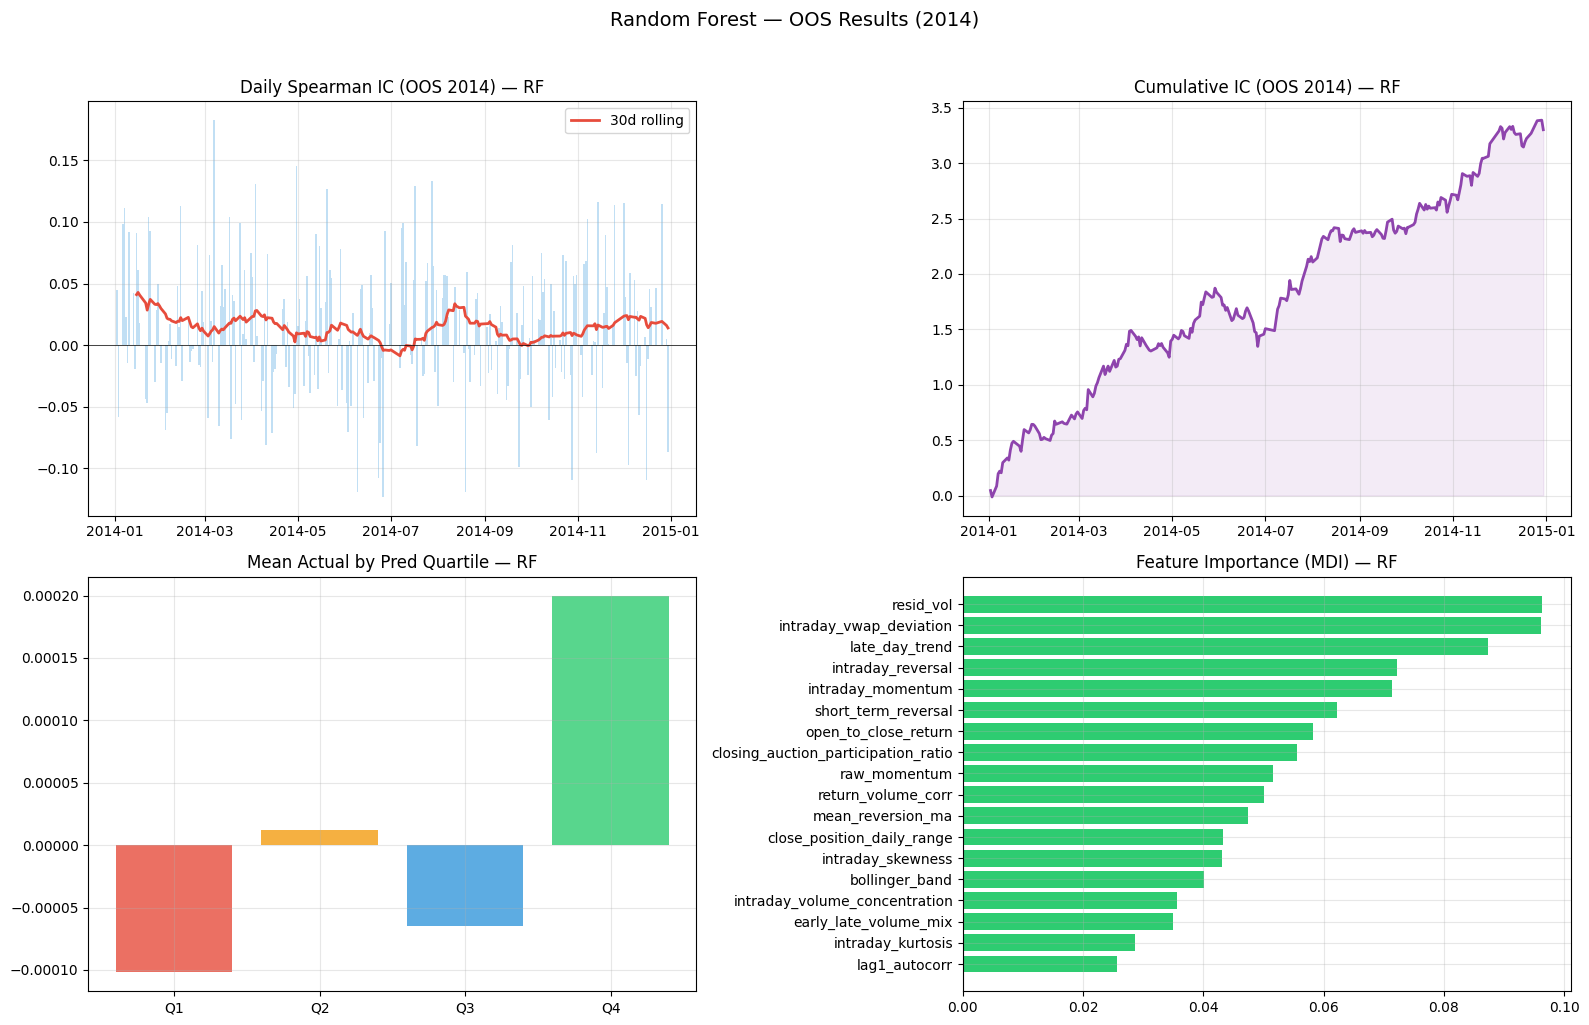

In [27]:
# ══════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Final Training (2010–2013) → OOS 2014
# Walk-forward skipped: train on full 2010-2013, evaluate on 2014.
# ══════════════════════════════════════════════════════════════════════════
import datetime

print(f"RF params (from HP search): {best_rf_params}\n")

print(f"[LOG] Fitting RF on all train (2010-2013): {len(X_full):,} rows...", flush=True)
t0 = time.time()
rf_final = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=42)
rf_final.fit(X_full, y_full)
print(f"[LOG]   ...fit done in {time.time()-t0:.1f}s at {datetime.datetime.now().isoformat()}", flush=True)

y_oos_pred_rf = rf_final.predict(X_oos)

oos_r2_rf = r2_score(y_oos, y_oos_pred_rf)
oos_ic_rf = spearmanr(y_oos, y_oos_pred_rf).correlation

rf_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_rf[m]
    if len(y_d) > 10:
        rf_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
rf_oos_daily_df = pd.DataFrame(rf_oos_daily)

print(f"\n{'='*70}")
print(f"RF OOS 2014:  R²={oos_r2_rf:+.6f}  IC={oos_ic_rf:+.4f}  "
      f"Hit%={(rf_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.bar(rf_oos_daily_df["date"], rf_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#3498db", width=1)
roll = rf_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — RF"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum = rf_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(rf_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(rf_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — RF"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
pred_q = pd.qcut(y_oos_pred_rf, 4, labels=[f"Q{i+1}" for i in range(4)])
bm = pd.Series(y_oos).groupby(pred_q).mean()
ax.bar(bm.index, bm.values,
       color=["#e74c3c","#f39c12","#3498db","#2ecc71"], alpha=0.8)
ax.set_title("Mean Actual by Pred Quartile — RF"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
fi = pd.DataFrame({"feature": feature_cols,
                    "importance": rf_final.feature_importances_})
fi = fi.sort_values("importance", ascending=True)
ax.barh(fi["feature"], fi["importance"], color="#2ecc71")
ax.set_title("Feature Importance (MDI) — RF"); ax.grid(True, alpha=0.3)

fig.suptitle("Random Forest — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

---

## Model 3: XGBoost

### Why XGBoost?

XGBoost adds **sequential boosting** on top of tree-based learning:
- Each new tree corrects residual errors from previous trees, achieving better bias-variance trade-off than bagging (RF).
- Built-in L2 regularization (`reg_lambda`) and learning rate shrinkage prevent overfitting.
- Gradient boosting is the dominant method in quant finance competitions (Kaggle, Two Sigma, etc.) for tabular data.
- Subsample + colsample per tree provide additional regularization similar to RF's feature bagging.

### HP Search Grid

| Hyperparameter | Values | Rationale |
|---------------|--------|-----------|
| `n_estimators` | 200, 500 | Number of boosting rounds |
| `max_depth` | 3, 5 | Shallow trees with boosting > deep trees |
| `learning_rate` | 0.01, 0.05 | Slow learning + more trees = better generalization |
| `subsample` | 0.7, 1.0 | Row subsampling for variance reduction |
| `colsample_bytree` | 0.5, 0.8 | Feature subsampling per tree |
| `reg_lambda` | 1.0 | L2 regularization (default, kept fixed) |

Same Purged 5-Fold CV → Walk-Forward → Final OOS pipeline.

In [28]:
# ══════════════════════════════════════════════════════════════════════════
# XGBOOST — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# Tunes reg_lambda (L2) AND decay_lambda (exponential sample-weight decay).
# decay_lambda controls how fast older training days are down-weighted:
#   sample_weight = exp(-decay_lambda * days_ago)
#   0.0  → uniform weights  |  0.005 → data ~200d ago weighted at exp(-1)≈0.37
# ══════════════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor
from itertools import product as iterproduct

xgb_param_grid = {
    "n_estimators":  [100, 500],
    "max_depth":     [3, 5],
    "learning_rate": [0.01, 0.1],
    "reg_lambda":    [0.1, 1.0, 10.0],
    "decay_lambda":  [0.0, 0.005],  # sample-weight decay (NOT an XGB param)
}

xgb_combos = [
    dict(zip(xgb_param_grid.keys(), vals))
    for vals in iterproduct(*xgb_param_grid.values())
]
print(f"XGB HP grid: {len(xgb_combos)} combos × 5 folds = {len(xgb_combos)*5} fits\n")

# df_hp / X_hp / y_hp defined by RF HP search cell; redefine here for safety
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values


def make_sample_weights(dates, decay_lambda):
    """Exponential time-decay weights: exp(-decay_lambda * days_ago).
    days_ago is rank-based (trading days), not calendar days."""
    if decay_lambda == 0.0:
        return None  # uniform — skip overhead
    unique_sorted = np.sort(pd.DatetimeIndex(dates).unique())
    rank = {d: i for i, d in enumerate(unique_sorted)}
    max_rank = len(unique_sorted) - 1
    days_ago = np.array([max_rank - rank[d] for d in dates])
    return np.exp(-decay_lambda * days_ago)


xgb_hp_results = []
t_hp = time.time()

for combo in xgb_combos:
    decay_lambda = combo["decay_lambda"]
    xgb_params   = {k: v for k, v in combo.items() if k != "decay_lambda"}

    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        sw = make_sample_weights(df_hp.index[tr_idx], decay_lambda)
        xgb_cv = XGBRegressor(**xgb_params, tree_method="hist",
                               n_jobs=1, random_state=42, verbosity=0)
        xgb_cv.fit(X_hp[tr_idx], y_hp[tr_idx], sample_weight=sw)
        y_pred = xgb_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))

    mean_ic = float(np.mean(fold_ics))
    xgb_hp_results.append({**combo, "mean_IC": mean_ic, "std_IC": float(np.std(fold_ics)),
                            "mean_R2": float(np.mean(fold_r2s))})
    print(f"  decay={decay_lambda}  {xgb_params}  →  "
          f"IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

xgb_hp_df    = pd.DataFrame(xgb_hp_results)
best_xgb_row = xgb_hp_df.loc[xgb_hp_df["mean_IC"].idxmax()]
best_xgb_params = {k: best_xgb_row[k] for k in xgb_param_grid}
for k in ["n_estimators", "max_depth"]:
    best_xgb_params[k] = int(best_xgb_params[k])

print(f"\n{'='*70}")
print(f"BEST XGB params: {best_xgb_params}")
print(f"  mean IC = {best_xgb_row['mean_IC']:+.4f} ± {best_xgb_row['std_IC']:.4f}")
print(f"  mean R² = {best_xgb_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")


XGB HP grid: 48 combos × 5 folds = 240 fits

  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 0.1}  →  IC=+0.0198 ± 0.0063  R²=+0.000318
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 0.1}  →  IC=+0.0182 ± 0.0067  R²=+0.000286
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 1.0}  →  IC=+0.0200 ± 0.0063  R²=+0.000325
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 1.0}  →  IC=+0.0183 ± 0.0068  R²=+0.000293
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 10.0}  →  IC=+0.0199 ± 0.0061  R²=+0.000351
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 10.0}  →  IC=+0.0183 ± 0.0068  R²=+0.000303
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'reg_lambda': 0.1}  →  IC=+0.0240 ± 0.0056  R²=+0.000270
  decay=0.005  {'n_estimators':

XGB params (from HP search): {'n_estimators': 500, 'max_depth': 3, 'learning_rate': np.float64(0.01), 'reg_lambda': np.float64(0.1), 'decay_lambda': np.float64(0.0)}

Fitting XGB on 431,755 rows...
Done in 7.1s

XGB OOS 2014:  R²=+0.000270  IC=+0.0169  Hit%=60.4%


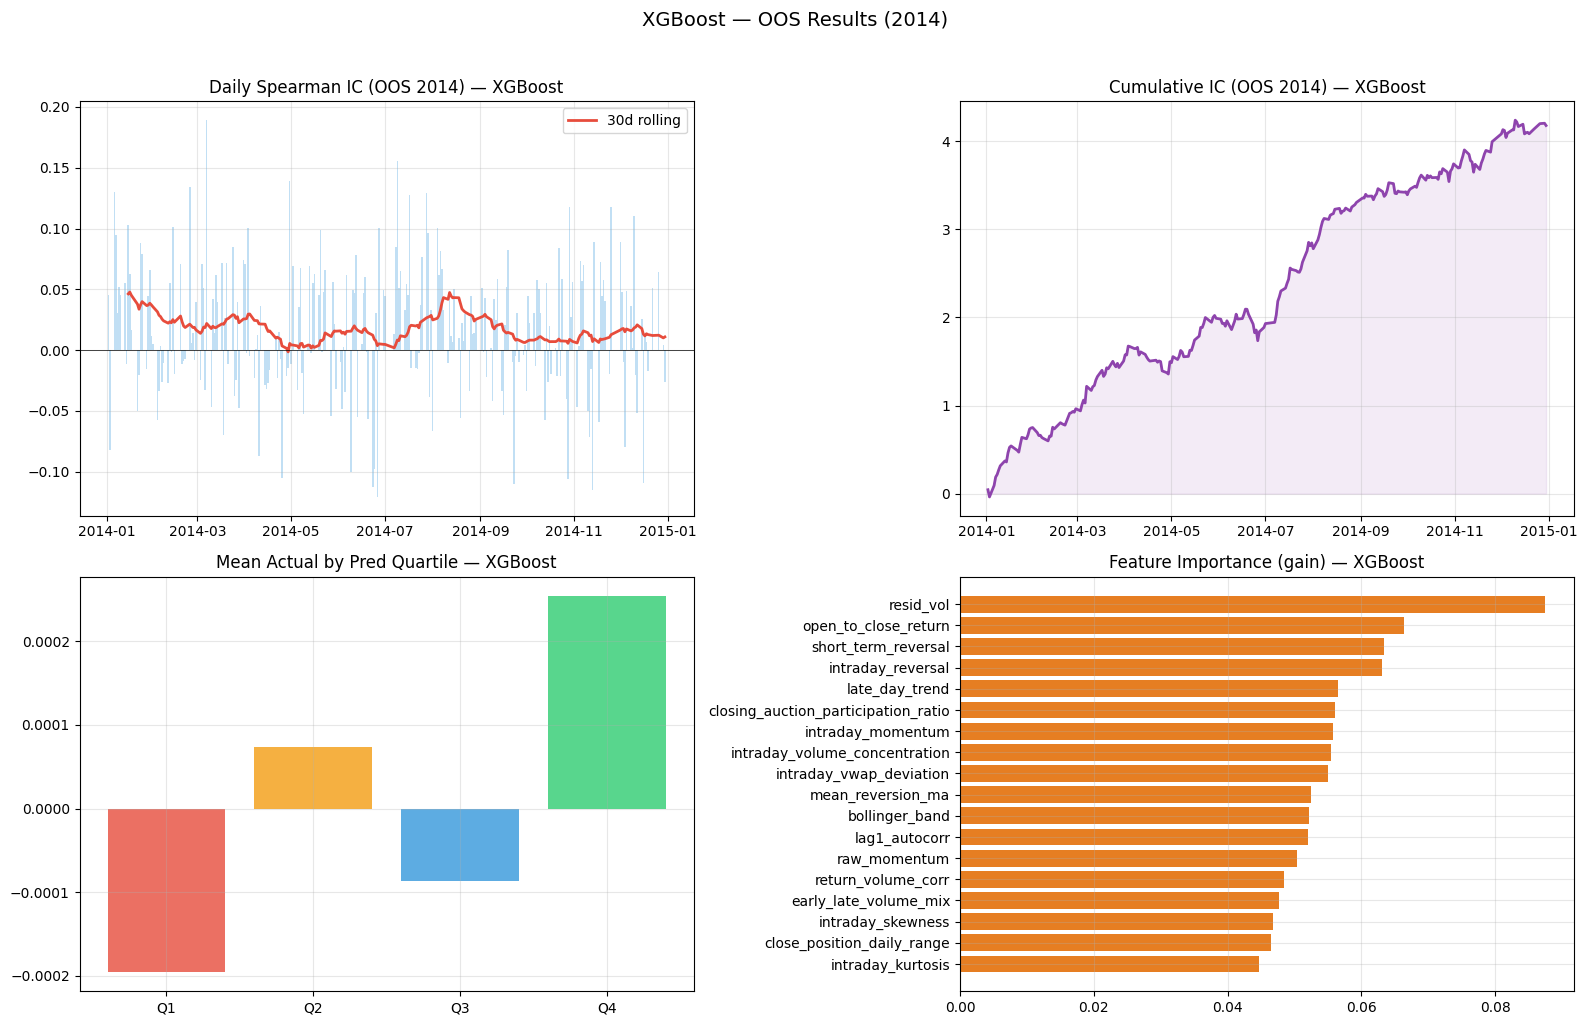

In [29]:
# ══════════════════════════════════════════════════════════════════════════
# XGBOOST — Final Training (2010–2013) → OOS 2014
# Walk-forward skipped: train on full 2010-2013, evaluate on 2014.
# (best_xgb_params includes tuned decay_lambda)
# ══════════════════════════════════════════════════════════════════════════

print(f"XGB params (from HP search): {best_xgb_params}\n")

best_decay_lambda   = best_xgb_params["decay_lambda"]
best_xgb_fit_params = {k: v for k, v in best_xgb_params.items() if k != "decay_lambda"}

sw_full   = make_sample_weights(df_train_norm.index, best_decay_lambda)
xgb_final = XGBRegressor(**best_xgb_fit_params, tree_method="hist",
                          n_jobs=1, random_state=42, verbosity=0)

print(f"Fitting XGB on {len(X_full):,} rows...", flush=True)
t0 = time.time()
xgb_final.fit(X_full, y_full, sample_weight=sw_full)
print(f"Done in {time.time()-t0:.1f}s", flush=True)

y_oos_pred_xgb = xgb_final.predict(X_oos)

oos_r2_xgb = r2_score(y_oos, y_oos_pred_xgb)
oos_ic_xgb = spearmanr(y_oos, y_oos_pred_xgb).correlation

xgb_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_xgb[m]
    if len(y_d) > 10:
        xgb_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
xgb_oos_daily_df = pd.DataFrame(xgb_oos_daily)

print(f"\n{'='*70}")
print(f"XGB OOS 2014:  R²={oos_r2_xgb:+.6f}  IC={oos_ic_xgb:+.4f}  "
      f"Hit%={(xgb_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.bar(xgb_oos_daily_df["date"], xgb_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#3498db", width=1)
roll = xgb_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — XGBoost"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum = xgb_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(xgb_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(xgb_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — XGBoost"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
pred_q = pd.qcut(y_oos_pred_xgb, 4, labels=[f"Q{i+1}" for i in range(4)])
bm = pd.Series(y_oos).groupby(pred_q).mean()
ax.bar(bm.index, bm.values,
       color=["#e74c3c","#f39c12","#3498db","#2ecc71"], alpha=0.8)
ax.set_title("Mean Actual by Pred Quartile — XGBoost"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
fi_xgb = pd.DataFrame({"feature": feature_cols,
                        "importance": xgb_final.feature_importances_})
fi_xgb = fi_xgb.sort_values("importance", ascending=True)
ax.barh(fi_xgb["feature"], fi_xgb["importance"], color="#e67e22")
ax.set_title("Feature Importance (gain) — XGBoost"); ax.grid(True, alpha=0.3)

fig.suptitle("XGBoost — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## Model : MLP (Multi-Layer Perceptron)
sklearn `MLPRegressor` — adam optimizer, early stopping, L2 regularization.  
HP search: 2 architectures × 2 α × 2 lr = 8 combos × 5 folds = 40 fits (Purged K-Fold, 2010–2012).  
Final fit on 2010–2013, evaluate on 2014 OOS.

In [30]:
# ══════════════════════════════════════════════════════════════════════════
# MLP — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# sklearn MLPRegressor with Adam optimizer and early stopping.
# Grid: 2 architectures × 2 L2 values × 2 learning rates = 8 combos × 5 folds
# ══════════════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPRegressor
from itertools import product as iterproduct

mlp_param_grid = {
    "hidden_layer_sizes": [(128, 64), (256, 128, 64)],
    "alpha":              [1e-4, 1e-3],         # L2 weight decay
    "learning_rate_init": [0.001, 0.005],
}

mlp_combos = [
    dict(zip(mlp_param_grid.keys(), vals))
    for vals in iterproduct(*mlp_param_grid.values())
]
print(f"MLP HP grid: {len(mlp_combos)} combos × 5 folds = {len(mlp_combos)*5} fits\n")

# df_hp / X_hp / y_hp / pkf defined in RF HP search cell; redefined here for safety
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

mlp_hp_results = []
t_hp = time.time()

for combo in mlp_combos:
    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        mlp_cv = MLPRegressor(
            **combo,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            solver="adam",
            random_state=42,
        )
        mlp_cv.fit(X_hp[tr_idx], y_hp[tr_idx])
        y_pred = mlp_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))

    mean_ic = float(np.mean(fold_ics))
    mlp_hp_results.append({
        "hidden_layer_sizes": str(combo["hidden_layer_sizes"]),
        "alpha":              combo["alpha"],
        "learning_rate_init": combo["learning_rate_init"],
        "mean_IC": mean_ic,
        "std_IC":  float(np.std(fold_ics)),
        "mean_R2": float(np.mean(fold_r2s)),
    })
    print(f"  {combo}  →  IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

mlp_hp_df    = pd.DataFrame(mlp_hp_results)
best_mlp_row = mlp_hp_df.loc[mlp_hp_df["mean_IC"].idxmax()]
best_mlp_params = {
    "hidden_layer_sizes": eval(best_mlp_row["hidden_layer_sizes"]),
    "alpha":              float(best_mlp_row["alpha"]),
    "learning_rate_init": float(best_mlp_row["learning_rate_init"]),
}

print(f"\n{'='*70}")
print(f"BEST MLP params: {best_mlp_params}")
print(f"  mean IC = {best_mlp_row['mean_IC']:+.4f} ± {best_mlp_row['std_IC']:.4f}")
print(f"  mean R² = {best_mlp_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")

MLP HP grid: 8 combos × 5 folds = 40 fits

  {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  →  IC=+0.0179 ± 0.0053  R²=+0.000194
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=+0.000019
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}  →  IC=+0.0191 ± 0.0065  R²=+0.000298
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000013
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  →  IC=+0.0240 ± 0.0048  R²=+0.000520
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000313
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}  →  IC=+nan ± nan  R²=-0.000018
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000084

BEST MLP p

In [31]:
# ══════════════════════════════════════════════════════════════════════════
# MLP — Final Training (2010–2013) → OOS 2014
# ══════════════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPRegressor

print(f"MLP params (from HP search): {best_mlp_params}\n")

mlp_final = MLPRegressor(
    **best_mlp_params,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    solver="adam",
    random_state=42,
)

print(f"Fitting MLP on {len(X_full):,} rows...", flush=True)
t0 = time.time()
mlp_final.fit(X_full, y_full)
print(f"Done in {time.time()-t0:.1f}s  ({mlp_final.n_iter_} iterations)", flush=True)

y_oos_pred_mlp = mlp_final.predict(X_oos)

oos_r2_mlp = r2_score(y_oos, y_oos_pred_mlp)
oos_ic_mlp = spearmanr(y_oos, y_oos_pred_mlp).correlation

mlp_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_mlp[m]
    if len(y_d) > 10:
        mlp_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
mlp_oos_daily_df = pd.DataFrame(mlp_oos_daily)

print(f"\n{'='*70}")
print(f"MLP OOS 2014:  R²={oos_r2_mlp:+.6f}  IC={oos_ic_mlp:+.4f}  "
      f"Hit%={(mlp_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")



MLP params (from HP search): {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}

Fitting MLP on 431,755 rows...
Done in 58.7s  (30 iterations)

MLP OOS 2014:  R²=-0.000170  IC=+0.0108  Hit%=58.0%


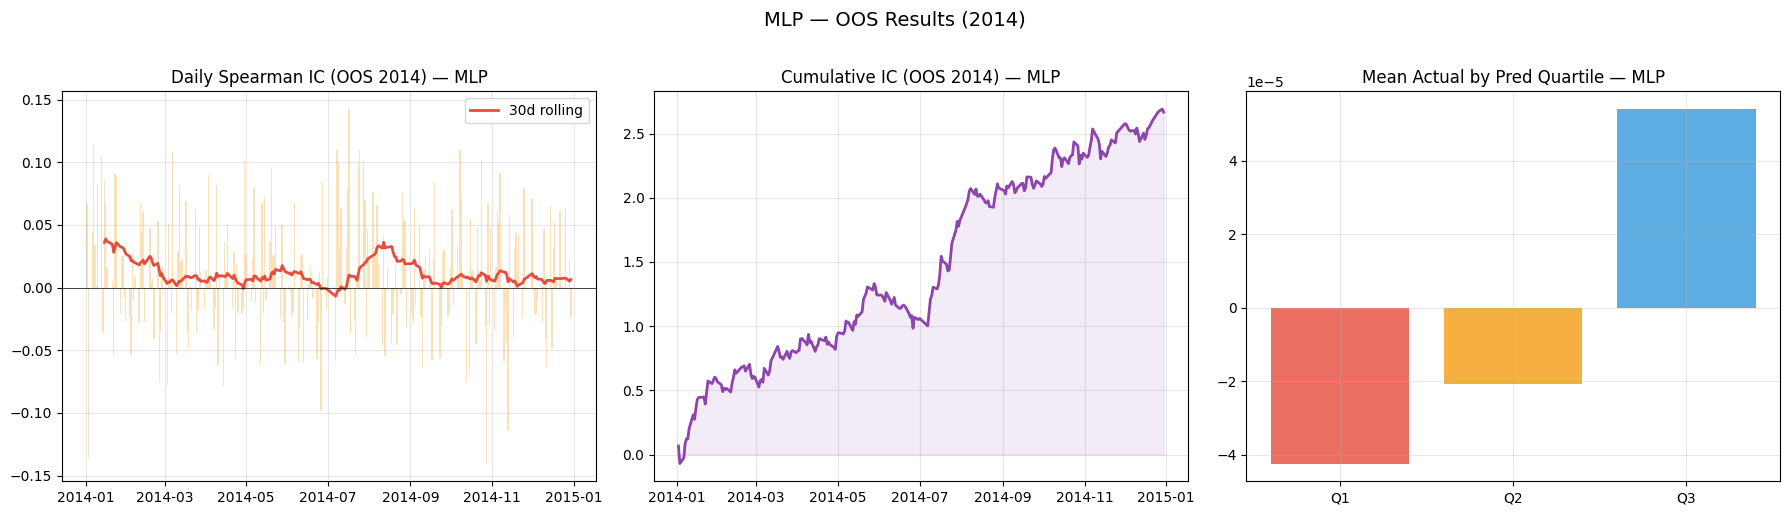

In [32]:
# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(mlp_oos_daily_df["date"], mlp_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#f39c12", width=1)
roll = mlp_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — MLP"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
cum = mlp_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(mlp_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(mlp_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — MLP"); ax.grid(True, alpha=0.3)

ax = axes[2]
pred_q = pd.qcut(y_oos_pred_mlp, 4, duplicates="drop")
bm = pd.Series(y_oos).groupby(pred_q).mean()
colors = ["#e74c3c","#f39c12","#3498db","#2ecc71"][:len(bm)]
ax.bar(range(len(bm)), bm.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(bm))); ax.set_xticklabels([f"Q{i+1}" for i in range(len(bm))])
ax.set_title("Mean Actual by Pred Quartile — MLP"); ax.grid(True, alpha=0.3)

fig.suptitle("MLP — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


MLP appears to be overfitting — let's try a **Residual MLP** with skip connections and BatchNorm for stronger regularization.

## Model: Residual MLP
PyTorch — residual blocks with BatchNorm + Dropout; trained with Adam and early stopping on validation IC.

In [55]:
# ══════════════════════════════════════════════════════════════════════════
# Residual MLP — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# Architecture: proj → N × (Linear→ReLU→Dropout→Linear + skip→ReLU)
# No BatchNorm — eliminates train/eval running-stats mismatch on OOS data.
# Grid: 2 hidden × 2 n_blocks × 2 dropouts = 8 combos × 5 folds = 40 fits
# ══════════════════════════════════════════════════════════════════════════
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Device ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")


# ── Model definition (no BatchNorm) ────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, d, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d, d),
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.net(x))          # skip connection


class ResidualMLP(nn.Module):
    def __init__(self, in_dim, hidden, n_blocks, dropout):
        super().__init__()
        self.proj   = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head   = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.head(self.blocks(self.proj(x))).squeeze(-1)


def train_resmlp(X_tr, y_tr, X_va, y_va, hidden, n_blocks, dropout,
                 lr=1e-3, max_epochs=60, patience=8, batch_size=4096,
                 stop_on="ic", device="cpu", sample_weight=None):
    """
    stop_on='ic'   → early stop on val Spearman IC  (HP search: pick best architecture)
    stop_on='loss' → early stop on val MSE loss      (final training: avoid regime overfit)
    sample_weight  → optional 1-D array of per-sample weights (e.g. sqrt(MDV63));
                     used only during training, not for val metric.
    """
    model = ResidualMLP(X_tr.shape[1], hidden, n_blocks, dropout).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_va, dtype=torch.float32, device=device)
    yv = torch.tensor(y_va, dtype=torch.float32, device=device)
    n  = len(Xt)

    # Build weight tensor (normalised so mean = 1, preserving gradient scale)
    if sample_weight is not None:
        wt = torch.tensor(sample_weight, dtype=torch.float32, device=device)
        wt = wt / wt.mean()          # mean-normalise
    else:
        wt = None

    val_loss_fn = nn.MSELoss()
    best_metric = np.inf if stop_on == "loss" else -np.inf
    best_state, wait = None, 0

    for _ in range(max_epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        for start in range(0, n, batch_size):
            idx  = perm[start : start + batch_size]
            pred = model(Xt[idx])
            if wt is not None:
                # Weighted MSE: mean over batch of w_i * (y_i - pred_i)^2
                loss = (wt[idx] * F.mse_loss(pred, yt[idx], reduction="none")).mean()
            else:
                loss = F.mse_loss(pred, yt[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pv_t     = model(Xv)
            val_loss = float(val_loss_fn(pv_t, yv).item())
            pv       = pv_t.cpu().numpy()
        val_ic = float(spearmanr(y_va, pv).correlation)

        metric   = val_loss if stop_on == "loss" else val_ic
        improved = (metric < best_metric) if stop_on == "loss" else (metric > best_metric)

        if improved:
            best_metric = metric
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            wait        = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, val_ic   # always return IC for reporting

Device: mps


In [34]:
# ══════════════════════════════════════════════════════════════════════════
# Residual MLP — Final Training (2010–2013) → OOS 2014
# Val split: last full year (2013) as held-out — same regime as walk-forward.
# Early stop on val LOSS (not IC) to avoid overfitting to one val period's rankings.
# ══════════════════════════════════════════════════════════════════════════
print(f"ResidualMLP params (from HP search): {best_resmlp_params}\n")
sys.stdout.flush()

X_full_f = X_full.astype(np.float32)
y_full_f = y_full.astype(np.float32)
X_oos_f  = X_oos.astype(np.float32)

# Use 2013 as val (purged temporal split, same logic as walk-forward)
train_mask_ft = df_train_norm.index.year < 2013
val_mask_ft   = df_train_norm.index.year == 2013
X_tr_f = df_train_norm.loc[train_mask_ft, feature_cols].values.astype(np.float32)
y_tr_f = df_train_norm.loc[train_mask_ft, target_col].values.astype(np.float32)
X_va_f = df_train_norm.loc[val_mask_ft, feature_cols].values.astype(np.float32)
y_va_f = df_train_norm.loc[val_mask_ft, target_col].values.astype(np.float32)

print(f"Train (2010–2012): {len(X_tr_f):,} rows  |  Val (2013): {len(X_va_f):,} rows")
print(f"Fitting ResidualMLP (stop_on=loss)...")
sys.stdout.flush()

t0 = time.time()
resmlp_final, best_val_ic = train_resmlp(
    X_tr_f, y_tr_f, X_va_f, y_va_f,
    **best_resmlp_params,
    max_epochs=100, patience=12, batch_size=4096,
    stop_on="loss", device=DEVICE,
)
print(f"Done in {time.time()-t0:.1f}s  (best val IC={best_val_ic:+.4f})")
sys.stdout.flush()

resmlp_final.eval()
with torch.no_grad():
    y_oos_pred_resmlp = resmlp_final(
        torch.tensor(X_oos_f, device=DEVICE)
    ).cpu().numpy()

oos_r2_resmlp = r2_score(y_oos, y_oos_pred_resmlp)
oos_ic_resmlp = spearmanr(y_oos, y_oos_pred_resmlp).correlation

resmlp_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_resmlp[m]
    if len(y_d) > 10:
        resmlp_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
resmlp_oos_daily_df = pd.DataFrame(resmlp_oos_daily)

print(f"\n{'='*70}")
print(f"ResidualMLP OOS 2014:  R²={oos_r2_resmlp:+.6f}  IC={oos_ic_resmlp:+.4f}  "
      f"Hit%={(resmlp_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")
sys.stdout.flush()

ResidualMLP params (from HP search): {'hidden': 128, 'n_blocks': 3, 'dropout': 0.3}

Train (2010–2012): 309,605 rows  |  Val (2013): 122,150 rows
Fitting ResidualMLP (stop_on=loss)...
Done in 43.6s  (best val IC=+0.0164)

ResidualMLP OOS 2014:  R²=+0.000061  IC=+0.0190  Hit%=65.3%


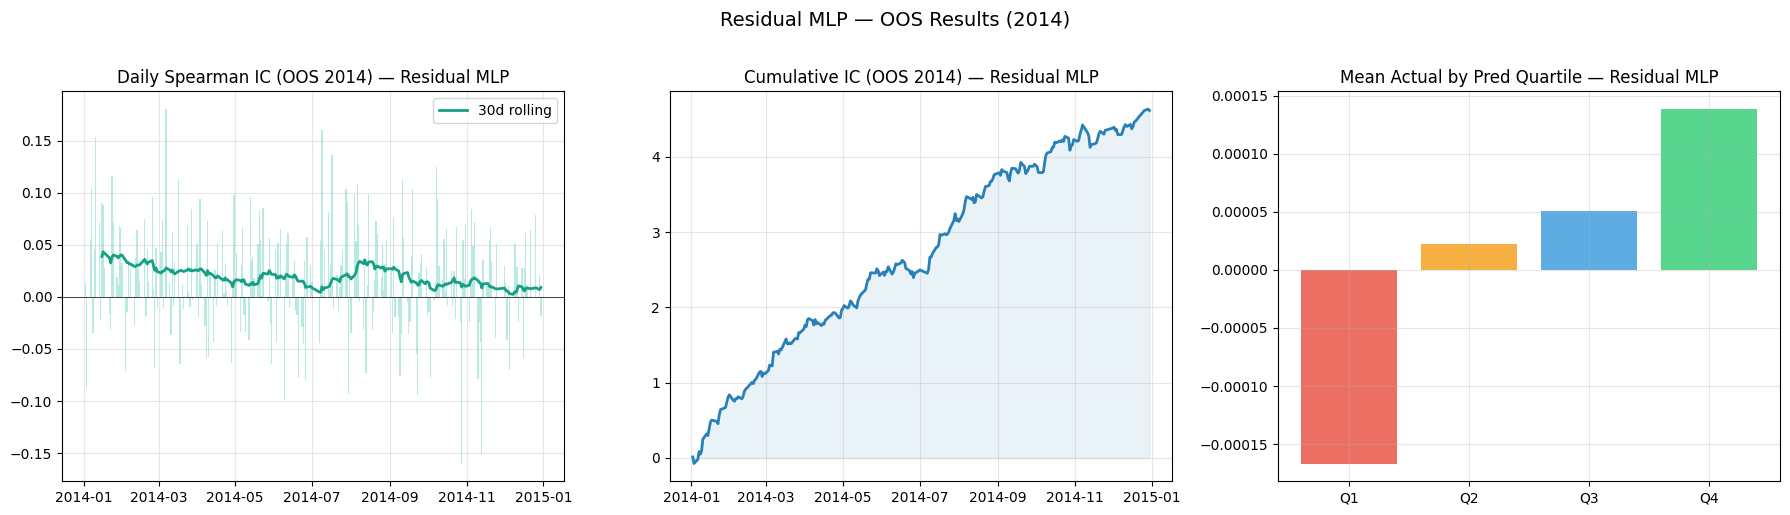

In [35]:
# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(resmlp_oos_daily_df["date"], resmlp_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#1abc9c", width=1)
roll = resmlp_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#16a085", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — Residual MLP"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
cum = resmlp_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(resmlp_oos_daily_df["date"], cum, color="#2980b9", lw=2)
ax.fill_between(resmlp_oos_daily_df["date"], 0, cum, alpha=0.1, color="#2980b9")
ax.set_title("Cumulative IC (OOS 2014) — Residual MLP"); ax.grid(True, alpha=0.3)

ax = axes[2]
pred_q = pd.qcut(y_oos_pred_resmlp, 4, duplicates="drop")
bm = pd.Series(y_oos).groupby(pred_q).mean()
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"][:len(bm)]
ax.bar(range(len(bm)), bm.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(bm))); ax.set_xticklabels([f"Q{i+1}" for i in range(len(bm))])
ax.set_title("Mean Actual by Pred Quartile — Residual MLP"); ax.grid(True, alpha=0.3)

fig.suptitle("Residual MLP — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

## Ensemble 

Ens-5 — Pairwise |Spearman ρ|:


,Ridge,RF,XGB,MLP,ResidMLP
Ridge,1.0000,0.7349,0.7535,0.8778,0.8311
RF,0.7349,1.0000,0.8519,0.7540,0.6399
XGB,0.7535,0.8519,1.0000,0.6963,0.6801
MLP,0.8778,0.7540,0.6963,1.0000,0.7152
ResidMLP,0.8311,0.6399,0.6801,0.7152,1.0000



Ens-5 — Diversity Weights:
  Ridge     : weight=0.195  avg |ρ|=0.799
  RF        : weight=0.201  avg |ρ|=0.745
  XGB       : weight=0.201  avg |ρ|=0.745
  MLP       : weight=0.199  avg |ρ|=0.761
  ResidMLP  : weight=0.204  avg |ρ|=0.717

Ens-3 (Ridge+RF+XGB) — Diversity Weights:
  Ridge     : weight=0.340  avg |ρ|=0.744
  RF        : weight=0.331  avg |ρ|=0.793
  XGB       : weight=0.329  avg |ρ|=0.803

Ens-5 (Div-Weighted, all 5): R²=+0.000102  IC=+0.0179  Hit%=62.0%
Ens-3 (Div-Weighted, top 3): R²=+0.000132  IC=+0.0173  Hit%=60.4%


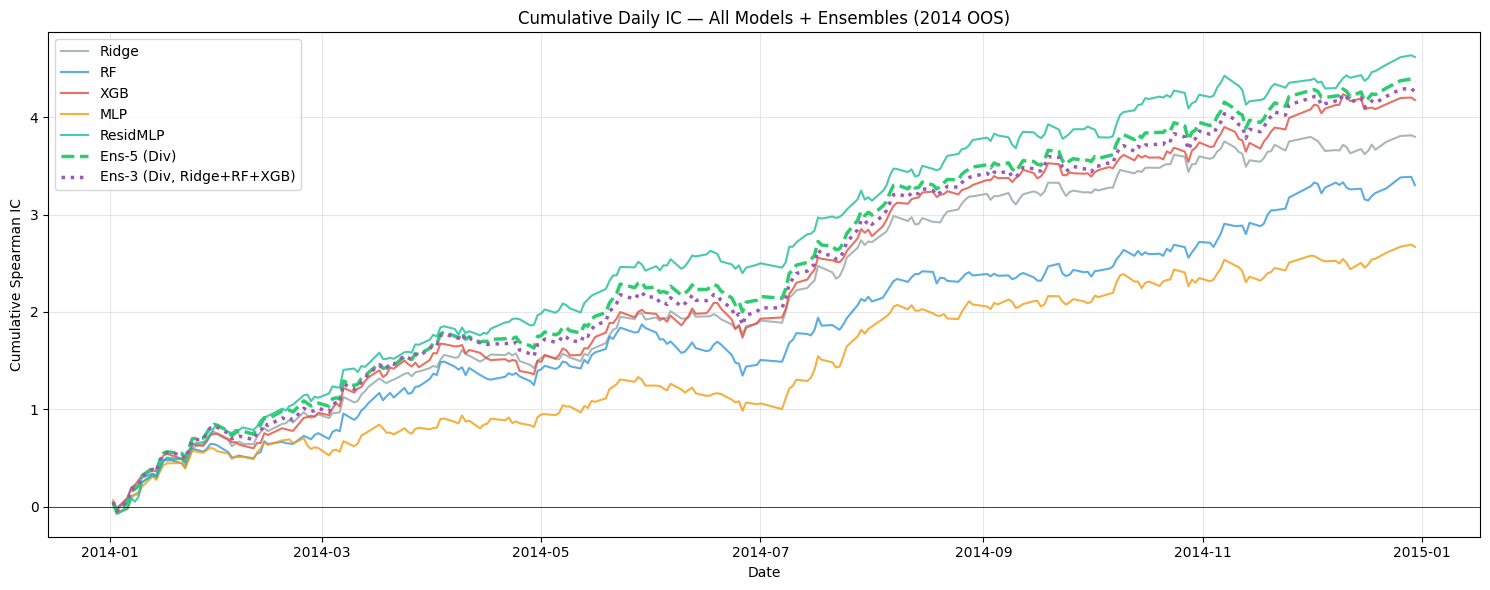

In [36]:
# ══════════════════════════════════════════════════════════════════════════
# ENSEMBLE
#   Ens-5 (Div-Weighted) : Ridge + RF + XGB + MLP + ResidualMLP
#   Ens-3 (Div-Weighted) : Ridge + RF + XGB only
# Both use diversity weights ∝ 1 / (1 + avg |Spearman ρ| with other members).
# ══════════════════════════════════════════════════════════════════════════

# ── Per-day IC helper ─────────────────────────────────────────────────────
def daily_ic_series(y_true, y_pred, dates):
    records = []
    for date in sorted(dates.unique()):
        m = np.asarray(dates == date)
        yd, pd_ = y_true[m], y_pred[m]
        if len(yd) > 10:
            records.append({"date": date,
                            "SpearmanIC": spearmanr(yd, pd_).correlation})
    return pd.DataFrame(records)


def diversity_weights(pred_matrix, names):
    """Compute diversity (inverse avg-correlation) weights for a set of model predictions."""
    n_m      = pred_matrix.shape[1]
    corr_mat = np.eye(n_m)
    for i in range(n_m):
        for j in range(i + 1, n_m):
            c = spearmanr(pred_matrix[:, i], pred_matrix[:, j]).correlation
            corr_mat[i, j] = corr_mat[j, i] = abs(c)
    avg_corr = np.array([(corr_mat[i].sum() - 1) / (n_m - 1) for i in range(n_m)])
    raw_w    = 1.0 / (1.0 + avg_corr)
    weights  = raw_w / raw_w.sum()
    corr_df  = pd.DataFrame(corr_mat, index=names, columns=names)
    return weights, avg_corr, corr_df


# ── Ens-5: all five models ─────────────────────────────────────────────────
preds_5 = {
    "Ridge":    y_oos_pred_ridge,
    "RF":       y_oos_pred_rf,
    "XGB":      y_oos_pred_xgb,
    "MLP":      y_oos_pred_mlp,
    "ResidMLP": y_oos_pred_resmlp,
}
names_5    = list(preds_5.keys())
mat_5      = np.column_stack(list(preds_5.values()))
w5, ac5, corr5_df = diversity_weights(mat_5, names_5)

print("Ens-5 — Pairwise |Spearman ρ|:")
display(corr5_df.round(4))
print("\nEns-5 — Diversity Weights:")
for name, w, ac in zip(names_5, w5, ac5):
    print(f"  {name:10s}: weight={w:.3f}  avg |ρ|={ac:.3f}")

y_oos_pred_ens5 = mat_5 @ w5


# ── Ens-3: Ridge + RF + XGB only ──────────────────────────────────────────
preds_3 = {k: preds_5[k] for k in ["Ridge", "RF", "XGB"]}
names_3  = list(preds_3.keys())
mat_3    = np.column_stack(list(preds_3.values()))
w3, ac3, corr3_df = diversity_weights(mat_3, names_3)

print("\nEns-3 (Ridge+RF+XGB) — Diversity Weights:")
for name, w, ac in zip(names_3, w3, ac3):
    print(f"  {name:10s}: weight={w:.3f}  avg |ρ|={ac:.3f}")

y_oos_pred_ens3 = mat_3 @ w3


# ── OOS metrics ───────────────────────────────────────────────────────────
ens5_daily = daily_ic_series(y_oos, y_oos_pred_ens5, df_test_norm.index)
ens3_daily = daily_ic_series(y_oos, y_oos_pred_ens3, df_test_norm.index)

oos_r2_ens5 = r2_score(y_oos, y_oos_pred_ens5)
oos_ic_ens5 = spearmanr(y_oos, y_oos_pred_ens5).correlation
oos_r2_ens3 = r2_score(y_oos, y_oos_pred_ens3)
oos_ic_ens3 = spearmanr(y_oos, y_oos_pred_ens3).correlation

print(f"\n{'='*70}")
print(f"Ens-5 (Div-Weighted, all 5): R²={oos_r2_ens5:+.6f}  IC={oos_ic_ens5:+.4f}  "
      f"Hit%={(ens5_daily['SpearmanIC']>0).mean()*100:.1f}%")
print(f"Ens-3 (Div-Weighted, top 3): R²={oos_r2_ens3:+.6f}  IC={oos_ic_ens3:+.4f}  "
      f"Hit%={(ens3_daily['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")


# ── Cumulative IC — all models + both ensembles ────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
palette = {"Ridge": "#95a5a6", "RF": "#3498db", "XGB": "#e74c3c",
           "MLP": "#f39c12", "ResidMLP": "#1abc9c"}
for name, y_pred in preds_5.items():
    daily = daily_ic_series(y_oos, y_pred, df_test_norm.index)
    ax.plot(daily["date"], daily["SpearmanIC"].cumsum(),
            label=name, color=palette[name], linewidth=1.5, alpha=0.8)
ax.plot(ens5_daily["date"], ens5_daily["SpearmanIC"].cumsum(),
        label="Ens-5 (Div)", color="#2ecc71", linewidth=2.5, linestyle="--")
ax.plot(ens3_daily["date"], ens3_daily["SpearmanIC"].cumsum(),
        label="Ens-3 (Div, Ridge+RF+XGB)", color="#9b59b6", linewidth=2.5, linestyle=":")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Spearman IC")
ax.set_title("Cumulative Daily IC — All Models + Ensembles (2014 OOS)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [37]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL COMPARISON — Ridge + RF + XGBoost + MLP + ResidualMLP + Ensembles
# ══════════════════════════════════════════════════════════════════════════

# Ridge results hardcoded from earlier run
ridge_oos_r2  = -0.0001
ridge_oos_ic  =  0.0155
ridge_oos_hit =  61.6

comparison = pd.DataFrame([
    {
        "Model":         "Ridge",
        "Best HPs":      "α=1000",
        "OOS R² 2014":   ridge_oos_r2,
        "OOS IC 2014":   ridge_oos_ic,
        "OOS Hit% 2014": ridge_oos_hit,
    },
    {
        "Model":         "Random Forest",
        "Best HPs":      f"d={best_rf_params['max_depth']}, n={best_rf_params['n_estimators']}, leaf={best_rf_params['min_samples_leaf']}",
        "OOS R² 2014":   oos_r2_rf,
        "OOS IC 2014":   oos_ic_rf,
        "OOS Hit% 2014": (rf_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "XGBoost",
        "Best HPs":      f"d={best_xgb_params['max_depth']}, n={best_xgb_params['n_estimators']}, lr={best_xgb_params['learning_rate']}, λ={best_xgb_params['decay_lambda']}",
        "OOS R² 2014":   oos_r2_xgb,
        "OOS IC 2014":   oos_ic_xgb,
        "OOS Hit% 2014": (xgb_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "MLP",
        "Best HPs":      f"layers={best_mlp_params['hidden_layer_sizes']}, α={best_mlp_params['alpha']}, lr={best_mlp_params['learning_rate_init']}",
        "OOS R² 2014":   oos_r2_mlp,
        "OOS IC 2014":   oos_ic_mlp,
        "OOS Hit% 2014": (mlp_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Residual MLP",
        "Best HPs":      f"hidden={best_resmlp_params['hidden']}, blocks={best_resmlp_params['n_blocks']}, drop={best_resmlp_params['dropout']}",
        "OOS R² 2014":   oos_r2_resmlp,
        "OOS IC 2014":   oos_ic_resmlp,
        "OOS Hit% 2014": (resmlp_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Ens-5 (Div-Weighted)",
        "Best HPs":      f"w={dict(zip(names_5, w5.round(3)))}",
        "OOS R² 2014":   oos_r2_ens5,
        "OOS IC 2014":   oos_ic_ens5,
        "OOS Hit% 2014": (ens5_daily["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Ens-3 (Div-Weighted, Ridge+RF+XGB)",
        "Best HPs":      f"w={dict(zip(names_3, w3.round(3)))}",
        "OOS R² 2014":   oos_r2_ens3,
        "OOS IC 2014":   oos_ic_ens3,
        "OOS Hit% 2014": (ens3_daily["SpearmanIC"] > 0).mean() * 100,
    },
])

print(f"{'='*90}")
print(f"{'MODEL COMPARISON — ALL MODELS + ENSEMBLES':^90}")
print(f"{'='*90}")
display(comparison.set_index("Model").round(4))

best_ic  = comparison.loc[comparison["OOS IC 2014"].idxmax(),    "Model"]
best_hit = comparison.loc[comparison["OOS Hit% 2014"].idxmax(), "Model"]
print(f"\nBest OOS IC:    {best_ic}")
print(f"Best OOS Hit%:  {best_hit}")

                        MODEL COMPARISON — ALL MODELS + ENSEMBLES                         


,Best HPs,OOS R² 2014,OOS IC 2014,OOS Hit% 2014
Model,,,,
Ridge,α=1000,-0.0001,0.0155,61.6000
Random Forest,"d=5, n=200, leaf=50",0.0000,0.0134,58.7755
XGBoost,"d=3, n=500, lr=0.01, λ=0.0",0.0003,0.0169,60.4082
MLP,"layers=(256, 128, 64), α=0.0001, lr=0.001",-0.0002,0.0108,57.9592
Residual MLP,"hidden=128, blocks=3, drop=0.3",0.0001,0.0190,65.3061
Ens-5 (Div-Weighted),"w={'Ridge': np.float64(0.195), 'RF': np.float6...",0.0001,0.0179,62.0408
"Ens-3 (Div-Weighted, Ridge+RF+XGB)","w={'Ridge': np.float64(0.34), 'RF': np.float64...",0.0001,0.0173,60.4082



Best OOS IC:    Residual MLP
Best OOS Hit%:  Residual MLP


### **Observations** :

Ensemble with the base models seem to be superior, probably because we dont have enough data to train neural nets(or they are just inferior in low signal to noise ratio environments), even residual MLP couldn't beat our base models(not surprising!)

## FINAL MODEL FIT AND OOS TESTING ON 2015

---

## True OOS Evaluation — 2015

Refit all five models on the **full 2010–2014 training set** (best HPs unchanged) and evaluate on 2015.  
The 2015 features are transformed with the **exact same clipping and normalization params** computed from 2010–2013 training data — no look-ahead.

In [ ]:
pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — Load & transform 2015 features
#
# Transformation order (must match training pipeline exactly):
#   1. build raw features from oos_data (cached → features_raw_oos2015.parquet)
#   2. clean_feature_panel  — NaN fill / warmup cutoff (same warmup_cutoff as train)
#   3. 5-MAD clipping       — using saved clip_params.joblib (from 2010–2013 train)
#   4. Stage 1 z-score      — subtract train mean / divide by train std (norm_params.joblib)
#   5. Stage 2 xsect rank   — per-date rank → N(0,1) inverse CDF (no stored params needed)
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time, joblib
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import norm as sp_norm
warnings.filterwarnings("ignore")

_project_root = Path.cwd().parent
for p in [str(_project_root), str(_project_root / "submission_files")]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR, ROOT_DIR
from feature_src.nan_handler import clean_feature_panel

OOS_DATA_DIR   = ROOT_DIR / "oos_data"
CACHE_RAW_2015 = FEATURE_DATA_DIR / "feature_together" / "features_raw_oos2015.parquet"
CACHE_NORM_2015 = FEATURE_DATA_DIR / "feature_together" / "features_norm_oos2015.parquet"

# ── 1a. Build or load raw 2015 features ───────────────────────────────────
if CACHE_NORM_2015.exists():
    print("✓ Cached normalized 2015 features found — loading directly.")
    df_2015_norm = pd.read_parquet(CACHE_NORM_2015)
else:
    if CACHE_RAW_2015.exists():
        print("✓ Cached raw 2015 features found — loading.")
        df_raw_2015 = pd.read_parquet(CACHE_RAW_2015)
    else:
        print("Building 2015 raw features from oos_data (this takes ~5-10 min)...")
        from main import load_intraday_data
        from feature_src.daily_data_loader import load_daily_data
        from feature_src.feature_engineering import build_daily_dataset
        import json, tempfile, os

        # Strip MAD filter from config (same as done for raw train/test)
        config_path = _project_root / "submission_files" / "feature_src" / "features_config.json"
        with open(config_path) as _f:
            _cfg = json.load(_f)
        for _section in ("intraday_features", "daily_features"):
            for _feat in _cfg.get(_section, []):
                _feat.pop("mad_filter", None)
        _tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
        json.dump(_cfg, _tmp, indent=2); _tmp.close()

        all_data_oos = load_intraday_data(OOS_DATA_DIR / "intraday_data", include_test=True)
        daily_data_oos = load_daily_data(daily_dir=OOS_DATA_DIR / "daily_data")
        df_raw_all = build_daily_dataset(
            all_data=all_data_oos,
            feature_config_path=_tmp.name,
            daily_data=daily_data_oos,
            include_target=True,
        )
        os.unlink(_tmp.name)

        # Keep only 2015
        df_raw_2015 = df_raw_all[pd.to_datetime(df_raw_all.index).year == 2015].copy()
        df_raw_2015.to_parquet(CACHE_RAW_2015)
        print(f"✓ Cached raw 2015 features ({len(df_raw_2015):,} rows) → {CACHE_RAW_2015.name}")

    # ── 1b. NaN cleaning ──────────────────────────────────────────────────
    # warmup_cutoff = same first date as training set (already past warmup)
    train_cutoff = df_train_norm.index.min()
    df_2015_clean = clean_feature_panel(
        df_raw_2015, drop_target_nan=True, warmup_cutoff=train_cutoff, verbose=False
    )
    print(f"After NaN clean: {len(df_2015_clean):,} rows")

    # ── 1c. 5-MAD clipping with SAVED train params ────────────────────────
    clip_params = joblib.load(FEATURE_DATA_DIR / "clip_params.joblib")
    df_2015_clipped = df_2015_clean.copy()
    for col, p in clip_params["features"].items():
        if col in df_2015_clipped.columns:
            df_2015_clipped[col] = df_2015_clipped[col].clip(lower=p["clip_lo"], upper=p["clip_hi"])
    # Clip target with saved target params (for evaluation consistency; not used in training)
    tp = clip_params["target"]
    df_2015_clipped["target_variable"] = df_2015_clipped["target_variable"].clip(
        lower=tp["clip_lo"], upper=tp["clip_hi"]
    )

    # ── 1d. Stage 1: z-score with SAVED train mean/std ────────────────────
    norm_params_saved = joblib.load(FEATURE_DATA_DIR / "norm_params.joblib")
    stage1 = norm_params_saved["stage1_params"]
    df_2015_s1 = df_2015_clipped.copy()
    for col in feature_cols:
        mu, std = stage1[col]["mean"], stage1[col]["std"]
        df_2015_s1[col] = (df_2015_s1[col] - mu) / std if std > 1e-12 else 0.0

    # ── 1e. Stage 2: cross-sectional rank-norm (per-date, on 2015 itself) ─
    def cross_sectional_rank_norm(df, cols):
        df_out = df.copy()
        for col in cols:
            ranked  = df_out.groupby(df_out.index)[col].rank(method="average", na_option="keep")
            counts  = df_out.groupby(df_out.index)[col].transform("count")
            df_out[col] = sp_norm.ppf((ranked - 0.5) / counts)
        return df_out

    df_2015_norm = cross_sectional_rank_norm(df_2015_s1, feature_cols)
    df_2015_norm.to_parquet(CACHE_NORM_2015)
    print(f"✓ Cached normalized 2015 features → {CACHE_NORM_2015.name}")

print(f"\n✓ 2015 data ready: {df_2015_norm.shape}  "
      f"({df_2015_norm.index.min().date()} → {df_2015_norm.index.max().date()})")
sys.stdout.flush()

X_2015 = df_2015_norm[feature_cols].values
y_2015 = df_2015_norm[target_col].values

✓ Cached normalized 2015 features found — loading directly.

✓ 2015 data ready: (122893, 20)  (2015-01-02 → 2015-12-30)


In [58]:
# ══════════════════════════════════════════════════════════════════════════
# MDV63 SAMPLE WEIGHTS — sqrt(MDV_63) per (Date, Id)
# PDF §3: use MDV63 as sample weights for fitting; √ mutes extreme values
# ══════════════════════════════════════════════════════════════════════════
import time
from pathlib import Path
from feature_src.daily_data_loader import load_daily_data

_root = Path.cwd().parent
_daily_train_dir = _root / "raw_data" / "data_daily"
_daily_oos_dir   = _root / "oos_data"  / "daily_data"

print("Loading daily data for MDV63 weights...")
t0 = time.time()
_daily_train = load_daily_data(daily_dir=_daily_train_dir)
_daily_oos   = load_daily_data(daily_dir=_daily_oos_dir)
_daily_all   = pd.concat([_daily_train, _daily_oos], ignore_index=True)
_daily_all["Date"] = pd.to_datetime(_daily_all["Date"])

# Deduplicate — oos_data daily may overlap with raw_data for some dates
_daily_mdv = (
    _daily_all[["Date", "Id", "MDV_63"]]
    .drop_duplicates(subset=["Date", "Id"], keep="last")
    .copy()
)
print(f"  Loaded {len(_daily_mdv):,} unique (Date, Id) rows in {time.time()-t0:.1f}s")


def _make_weights(norm_df: pd.DataFrame) -> np.ndarray:
    """Return sqrt(MDV_63) array aligned row-for-row to norm_df."""
    df_r = norm_df.reset_index()[["Date", "Id"]].copy()
    df_r["Date"] = pd.to_datetime(df_r["Date"])
    merged = df_r.merge(_daily_mdv, on=["Date", "Id"], how="left")
    assert len(merged) == len(df_r), \
        f"Merge expanded rows: {len(merged)} vs {len(df_r)} — check for duplicate (Date,Id) in _daily_mdv"
    mdv = merged["MDV_63"].values.astype(float)
    med = np.nanmedian(mdv[mdv > 0])
    mdv = np.where(np.isnan(mdv) | (mdv <= 0), med, mdv)
    return np.sqrt(mdv)


# ── Compute aligned weight arrays ─────────────────────────────────────────
w_train      = _make_weights(df_train_norm)
w_test       = _make_weights(df_test_norm)
w_train_full = _make_weights(pd.concat([df_train_norm, df_test_norm]).sort_index())
w_2015       = _make_weights(df_2015_norm)

print(f"Weight arrays ready:")
print(f"  w_train      {w_train.shape},      mean={w_train.mean():.0f}")
print(f"  w_test       {w_test.shape},       mean={w_test.mean():.0f}")
print(f"  w_train_full {w_train_full.shape}, mean={w_train_full.mean():.0f}")
print(f"  w_2015       {w_2015.shape},       mean={w_2015.mean():.0f}")

Loading daily data for MDV63 weights...


Loading daily data: 100%|██████████| 1510/1510 [00:01<00:00, 867.10it/s] 


  Loaded 755,000 unique (Date, Id) rows in 5.5s
Weight arrays ready:
  w_train      (431755,),      mean=12674
  w_test       (121866,),       mean=13545
  w_train_full (553621,), mean=12866
  w_2015       (122893,),       mean=14099


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — Refit all 5 models on 2010–2014 with sqrt(MDV63) sample weights
# df_train_full = df_train_norm (2010–2013) + df_test_norm (2014)
# ResidualMLP: train on 2010–2013, val on 2014 for early stopping
# ══════════════════════════════════════════════════════════════════════════
import shutil
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import xgboost as xgb
import torch
import joblib

# ── Full 2010–2014 training set ────────────────────────────────────────────
df_train_full = pd.concat([df_train_norm, df_test_norm]).sort_index()
X_tr_full = df_train_full[feature_cols].values
y_tr_full = df_train_full[target_col].values
print(f"2010–2014 training set: {df_train_full.shape}  "
      f"({df_train_full.index.min().date()} → {df_train_full.index.max().date()})")
print(f"Sample weights: sqrt(MDV63), shape={w_train_full.shape}, "
      f"range=[{w_train_full.min():.0f}, {w_train_full.max():.0f}]")

# ── Ridge ──────────────────────────────────────────────────────────────────
print("\nFitting Ridge (weighted)...", flush=True); t0 = time.time()
ridge_2015 = Ridge(alpha=1000)
ridge_2015.fit(X_tr_full, y_tr_full, sample_weight=w_train_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── Random Forest ──────────────────────────────────────────────────────────
print("Fitting RF (weighted)...", flush=True); t0 = time.time()
rf_2015 = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_2015.fit(X_tr_full, y_tr_full, sample_weight=w_train_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── XGBoost ────────────────────────────────────────────────────────────────
print("Fitting XGBoost (weighted)...", flush=True); t0 = time.time()
xgb_2015 = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1,
                              verbosity=0, eval_metric="rmse")
xgb_2015.fit(X_tr_full, y_tr_full, sample_weight=w_train_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── sklearn MLP — no native sample_weight support; train unweighted ────────
print("Fitting MLP (unweighted — MLPRegressor lacks sample_weight)...", flush=True)
t0 = time.time()
mlp_2015 = MLPRegressor(**best_mlp_params, max_iter=300, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=15,
                         solver="adam", random_state=42)
mlp_2015.fit(X_tr_full, y_tr_full)
print(f"  Done in {time.time()-t0:.1f}s  ({mlp_2015.n_iter_} iters)")

# ── Residual MLP — weighted MSE loss; train on 2010–2013, val on 2014 ─────
print("Fitting ResidualMLP (weighted)...", flush=True); t0 = time.time()
_tr_mask = df_train_full.index.year < 2014
_va_mask  = df_train_full.index.year == 2014
X_tr_nn   = df_train_full.loc[_tr_mask, feature_cols].values.astype(np.float32)
y_tr_nn   = df_train_full.loc[_tr_mask, target_col].values.astype(np.float32)
X_va_nn   = df_train_full.loc[_va_mask, feature_cols].values.astype(np.float32)
y_va_nn   = df_train_full.loc[_va_mask, target_col].values.astype(np.float32)
w_tr_nn   = w_train_full[_tr_mask]    # weights for 2010–2013 split

resmlp_2015, _val_ic = train_resmlp(
    X_tr_nn, y_tr_nn, X_va_nn, y_va_nn,
    **best_resmlp_params,
    max_epochs=100, patience=12, batch_size=4096,
    stop_on="loss", device=DEVICE,
    sample_weight=w_tr_nn,
)
print(f"  Done in {time.time()-t0:.1f}s  (val IC={_val_ic:+.4f})")
sys.stdout.flush()
print("\n✓ All models fitted on 2010–2014 with sqrt(MDV63) weights.")

# ══════════════════════════════════════════════════════════════════════════
# Save all models + transformation params → model_src/saved_models/
# model_predictor.py (Mode 2) reads everything from this one directory.
# ══════════════════════════════════════════════════════════════════════════
MODEL_SAVE_DIR = _project_root / "submission_files" / "model_src" / "saved_models"
MODEL_SAVE_DIR.mkdir(exist_ok=True)

joblib.dump(ridge_2015,              MODEL_SAVE_DIR / "ridge.joblib")
joblib.dump(rf_2015,                 MODEL_SAVE_DIR / "rf.joblib")
joblib.dump(xgb_2015,                MODEL_SAVE_DIR / "xgb.joblib")
joblib.dump(mlp_2015,                MODEL_SAVE_DIR / "mlp.joblib")
torch.save(resmlp_2015.state_dict(), MODEL_SAVE_DIR / "resmlp_state.pt")
joblib.dump(best_resmlp_params,      MODEL_SAVE_DIR / "resmlp_params.joblib")
joblib.dump({"feature_cols": feature_cols, "target_col": target_col},
            MODEL_SAVE_DIR / "feature_info.joblib")

shutil.copy(FEATURE_DATA_DIR / "clip_params.joblib", MODEL_SAVE_DIR / "clip_params.joblib")
shutil.copy(FEATURE_DATA_DIR / "norm_params.joblib", MODEL_SAVE_DIR / "norm_params.joblib")

print(f"\n✓ All models + params saved → {MODEL_SAVE_DIR}")
print(f"  Files: {sorted(f.name for f in MODEL_SAVE_DIR.iterdir())}")

2010–2014 training set: (553621, 20)  (2010-06-25 → 2014-12-30)
Sample weights: sqrt(MDV63), shape=(553621,), range=[6615, 115522]

Fitting Ridge (weighted)...


  Done in 0.1s
Fitting RF (weighted)...
  Done in 33.4s
Fitting XGBoost (weighted)...
  Done in 5.0s
Fitting MLP (unweighted — MLPRegressor lacks sample_weight)...
  Done in 65.5s  (26 iters)
Fitting ResidualMLP (weighted)...
  Done in 50.0s  (val IC=+0.0125)

✓ All models fitted on 2010–2014 with sqrt(MDV63) weights.


✓ Ensemble weights saved → /Users/chaithanyapakala/Downloads/MTH9899_ProjectFinal/submission_files/model_src/saved_models/ensemble_weights.joblib
  Ridge                           R²=-0.000016  IC=+0.0086  Hit%=55.5%
  RF                              R²=+0.000204  IC=+0.0103  Hit%=59.5%
  XGB                             R²=-0.000300  IC=+0.0084  Hit%=55.5%
  MLP                             R²=+0.000036  IC=+0.0058  Hit%=57.5%
  ResidMLP                        R²=-0.000286  IC=+0.0049  Hit%=54.3%
  Ens-5 (Div)                     R²=+0.000098  IC=+0.0086  Hit%=55.5%
  Ens-3 (Div, Ridge+RF+XGB)       R²=+0.000094  IC=+0.0092  Hit%=58.7%

                        2015 TRUE OOS RESULTS                         


,OOS R² 2015,OOS IC 2015,OOS Hit% 2015
Model,,,
Ridge,-0.0000,0.0086,55.4656
RF,0.0002,0.0103,59.5142
XGB,-0.0003,0.0084,55.4656
MLP,0.0000,0.0058,57.4899
ResidMLP,-0.0003,0.0049,54.2510
Ens-5 (Div),0.0001,0.0086,55.4656
"Ens-3 (Div, Ridge+RF+XGB)",0.0001,0.0092,58.7045



Best OOS IC 2015:   RF
Best OOS Hit% 2015: RF


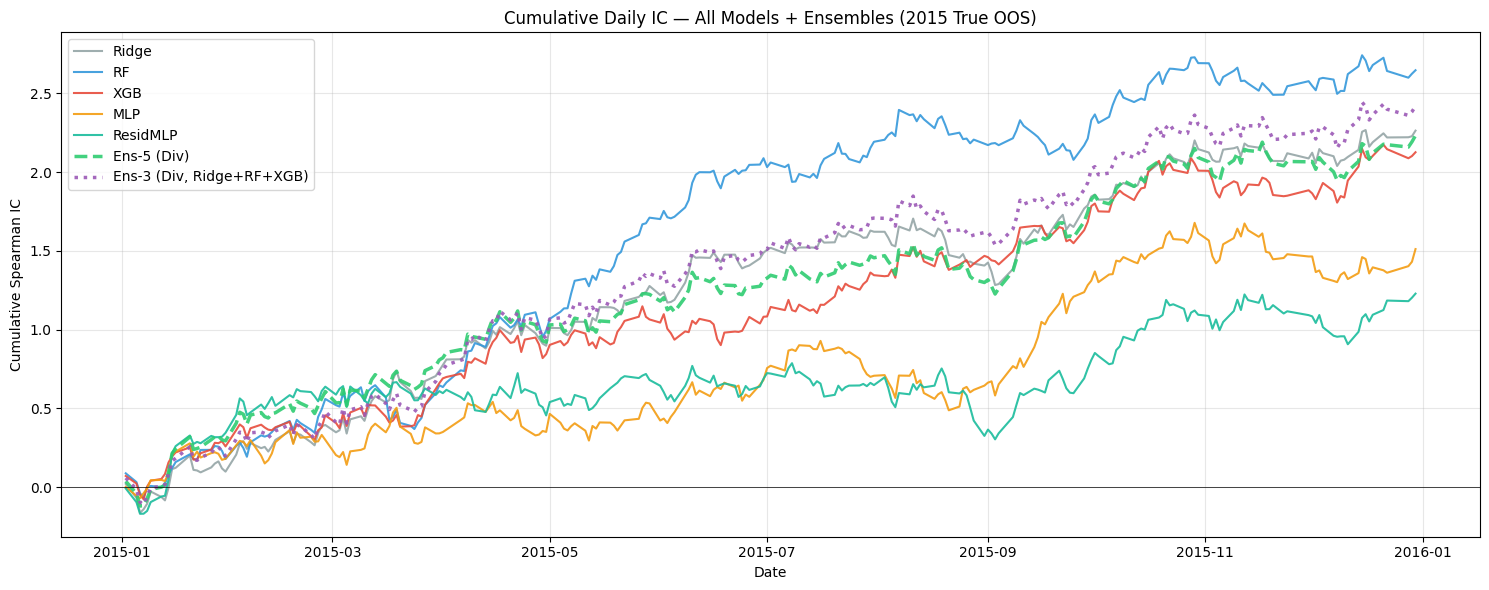

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — OOS 2015 predictions, ensembles, metrics & comparison
# ══════════════════════════════════════════════════════════════════════════

# ── Predictions ────────────────────────────────────────────────────────────
resmlp_2015.eval()
with torch.no_grad():
    _resmlp_pred = resmlp_2015(
        torch.tensor(X_2015.astype(np.float32), device=DEVICE)
    ).cpu().numpy()

preds_2015 = {
    "Ridge":    ridge_2015.predict(X_2015),
    "RF":       rf_2015.predict(X_2015),
    "XGB":      xgb_2015.predict(X_2015),
    "MLP":      mlp_2015.predict(X_2015),
    "ResidMLP": _resmlp_pred,
}

# ── Ensembles ──────────────────────────────────────────────────────────────
mat_2015_5 = np.column_stack(list(preds_2015.values()))
w2015_5, _, _ = diversity_weights(mat_2015_5, list(preds_2015.keys()))
pred_ens5_2015 = mat_2015_5 @ w2015_5

mat_2015_3 = np.column_stack([preds_2015[k] for k in ["Ridge", "RF", "XGB"]])
w2015_3, _, _ = diversity_weights(mat_2015_3, ["Ridge", "RF", "XGB"])
pred_ens3_2015 = mat_2015_3 @ w2015_3

# Save ensemble weights now that we have them
joblib.dump(
    {"w5": w2015_5, "names_5": list(preds_2015.keys()),
     "w3": w2015_3, "names_3": ["Ridge", "RF", "XGB"]},
    MODEL_SAVE_DIR / "ensemble_weights.joblib",
)
print(f"✓ Ensemble weights saved → {MODEL_SAVE_DIR / 'ensemble_weights.joblib'}")

# ── Per-day IC helper (reuse from ensemble cell) ───────────────────────────
def _daily_ic(y_true, y_pred, dates):
    recs = []
    for d in sorted(dates.unique()):
        m = np.asarray(dates == d)
        yd, pd_ = y_true[m], y_pred[m]
        if len(yd) > 10:
            recs.append({"date": d, "SpearmanIC": spearmanr(yd, pd_).correlation})
    return pd.DataFrame(recs)

# ── OOS 2015 metrics ────────────────────────────────────────────────────────
rows_2015 = []
all_preds_2015 = {**preds_2015,
                  "Ens-5 (Div)":              pred_ens5_2015,
                  "Ens-3 (Div, Ridge+RF+XGB)": pred_ens3_2015}

for name, pred in all_preds_2015.items():
    daily = _daily_ic(y_2015, pred, df_2015_norm.index)
    rows_2015.append({
        "Model":         name,
        "OOS R² 2015":   r2_score(y_2015, pred),
        "OOS IC 2015":   spearmanr(y_2015, pred).correlation,
        "OOS Hit% 2015": (daily["SpearmanIC"] > 0).mean() * 100,
    })
    print(f"  {name:30s}  R²={rows_2015[-1]['OOS R² 2015']:+.6f}  "
          f"IC={rows_2015[-1]['OOS IC 2015']:+.4f}  "
          f"Hit%={rows_2015[-1]['OOS Hit% 2015']:.1f}%", flush=True)

df_2015_results = pd.DataFrame(rows_2015).set_index("Model")

print(f"\n{'='*70}")
print(f"{'2015 TRUE OOS RESULTS':^70}")
print(f"{'='*70}")
display(df_2015_results.round(4))
best_ic_2015 = df_2015_results["OOS IC 2015"].idxmax()
print(f"\nBest OOS IC 2015:   {best_ic_2015}")
print(f"Best OOS Hit% 2015: {df_2015_results['OOS Hit% 2015'].idxmax()}")

# ── Cumulative IC plot — 2015 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
palette_2015 = {"Ridge": "#95a5a6", "RF": "#3498db", "XGB": "#e74c3c",
                "MLP": "#f39c12", "ResidMLP": "#1abc9c",
                "Ens-5 (Div)": "#2ecc71", "Ens-3 (Div, Ridge+RF+XGB)": "#9b59b6"}
ls_map = {**{k: "-" for k in preds_2015},
          "Ens-5 (Div)": "--", "Ens-3 (Div, Ridge+RF+XGB)": ":"}
lw_map = {**{k: 1.5 for k in preds_2015},
          "Ens-5 (Div)": 2.5, "Ens-3 (Div, Ridge+RF+XGB)": 2.5}

for name, pred in all_preds_2015.items():
    daily = _daily_ic(y_2015, pred, df_2015_norm.index)
    ax.plot(daily["date"], daily["SpearmanIC"].cumsum(),
            label=name, color=palette_2015[name],
            linewidth=lw_map[name], linestyle=ls_map[name], alpha=0.9)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Spearman IC")
ax.set_title("Cumulative Daily IC — All Models + Ensembles (2015 True OOS)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

,Id,intraday_momentum,intraday_reversal,resid_vol,intraday_skewness,early_late_volume_mix,return_volume_corr,lag1_autocorr,closing_auction_participation_ratio,intraday_kurtosis,intraday_vwap_deviation,intraday_volume_concentration,late_day_trend,target_variable,mean_reversion_ma,short_term_reversal,bollinger_band,raw_momentum,open_to_close_return,close_position_daily_range
Date,,,,,,,,,,,,,,,,,,,,
2010-06-25,BBG000B9WH86,-0.291950,0.187044,0.099512,0.244414,0.140568,-0.197424,-1.111716,-1.430969,-0.135424,-0.079051,0.213034,-0.239168,0.005181,1.430969,0.690567,-1.030350,-0.038220,0.345558,0.254926
2010-06-25,BBG000B9WJ73,0.536717,0.490212,-0.329378,-0.109758,-0.416794,0.361829,0.313284,0.971497,2.742488,0.723273,0.805152,1.555115,-0.007089,0.473048,1.590205,1.160280,-0.743272,2.047078,0.329378
2010-06-25,BBG000B9XRY4,0.877747,-1.056696,0.710100,-1.102314,-1.338007,0.270747,1.056696,-2.219941,-0.478754,1.111716,-1.301494,-0.495966,0.004783,-1.953056,-0.939331,-0.478754,2.284235,-0.627262,-0.135424
2010-06-25,BBG000B9XYV2,0.340155,0.495966,0.197424,0.033122,-0.176685,0.313284,-0.104633,0.478754,0.048419,1.102314,1.888618,1.459931,0.028565,-0.862866,0.548522,1.325639,1.047833,0.658585,2.068235
2010-06-25,BBG000B9ZXB4,0.524985,0.770410,1.093008,-0.495966,0.819324,-2.219941,0.979697,0.383675,0.161181,0.826472,1.030350,-0.427934,-0.000918,0.444745,-1.325639,-0.777283,0.908108,-1.376396,-1.140531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31,BBG002S5ZRF9,-2.031852,2.073211,-1.273583,1.100569,-0.267406,0.373421,-0.083147,-1.672745,-0.298842,-1.596211,-0.433490,1.451695,0.016823,-1.091392,-1.512046,0.108430,1.864518,-1.251250,-0.319964
2013-12-31,BBG0035LY913,-0.558790,1.064398,-0.842339,-0.330577,1.038157,1.197983,0.886214,-0.103368,-0.406005,-0.856780,-1.958249,-0.205285,-0.006078,0.189887,-1.296570,-0.200147,-0.184765,-0.987713,-1.284992
2013-12-31,BBG003641015,0.472533,0.466913,-0.495167,-0.886214,2.224655,-1.012613,-0.600470,0.231059,0.411477,0.661905,-1.958249,0.806979,-0.008868,1.273583,1.633282,0.489486,0.073049,1.614469,1.218875


---

## Visualizations

The following cells produce all visualizations referenced in the white paper:

1. **2014 Prediction Setup** — Consolidate 2014 predictions into a unified dict  
2. **Feature Importance** — MDI (RF built-in) and MDA (permutation importance on 2015 OOS)  
3. **HP Sensitivity Curves** — Cross-validated IC vs hyperparameters for all 5 models  
4. **Prediction Distributions** — Histograms of model predictions (2014 and 2015)  
5. **Bin Analysis** — Mean realized return per prediction quartile (2014 and 2015)  
6. **Rolling 30-day IC** — Model IC stability over time (2014 and 2015)  
7. **Alpha Drift Plot** — Intraday CumReturnResid path conditioned on prediction quartile (T-1 to T+1)

In [41]:
# ══════════════════════════════════════════════════════════════════════════
# VIZ SETUP — Consolidate 2014 predictions + shared helpers
# ══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# ── 2014 predictions dict (mirrors preds_2015 structure) ──────────────────
preds_2014 = {
    "Ridge":                     y_oos_pred_ridge,
    "RF":                        y_oos_pred_rf,
    "XGB":                       y_oos_pred_xgb,
    "MLP":                       y_oos_pred_mlp,
    "ResidMLP":                  y_oos_pred_resmlp,
    "Ens-5 (Div)":               y_oos_pred_ens5,
    "Ens-3 (Div, Ridge+RF+XGB)": y_oos_pred_ens3,
}
y_2014    = y_oos
dates_2014 = df_test_norm.index
dates_2015 = df_2015_norm.index

# ── Palette + style ────────────────────────────────────────────────────────
PALETTE = {
    "Ridge":                     "#95a5a6",
    "RF":                        "#3498db",
    "XGB":                       "#e74c3c",
    "MLP":                       "#f39c12",
    "ResidMLP":                  "#1abc9c",
    "Ens-5 (Div)":               "#2ecc71",
    "Ens-3 (Div, Ridge+RF+XGB)": "#9b59b6",
}

# ── Per-day IC helper ──────────────────────────────────────────────────────
def daily_ic(y_true, y_pred, dates):
    rows = []
    for d in sorted(pd.DatetimeIndex(dates).unique()):
        m = np.asarray(dates == d)
        yd, pd_ = y_true[m], y_pred[m]
        if len(yd) > 10:
            rows.append({"date": d, "IC": spearmanr(yd, pd_).correlation})
    return pd.DataFrame(rows).set_index("date")["IC"]

print("✓ Visualization setup complete.")

✓ Visualization setup complete.


Computing MDA permutation importance on 2015 OOS (n_repeats=15)...


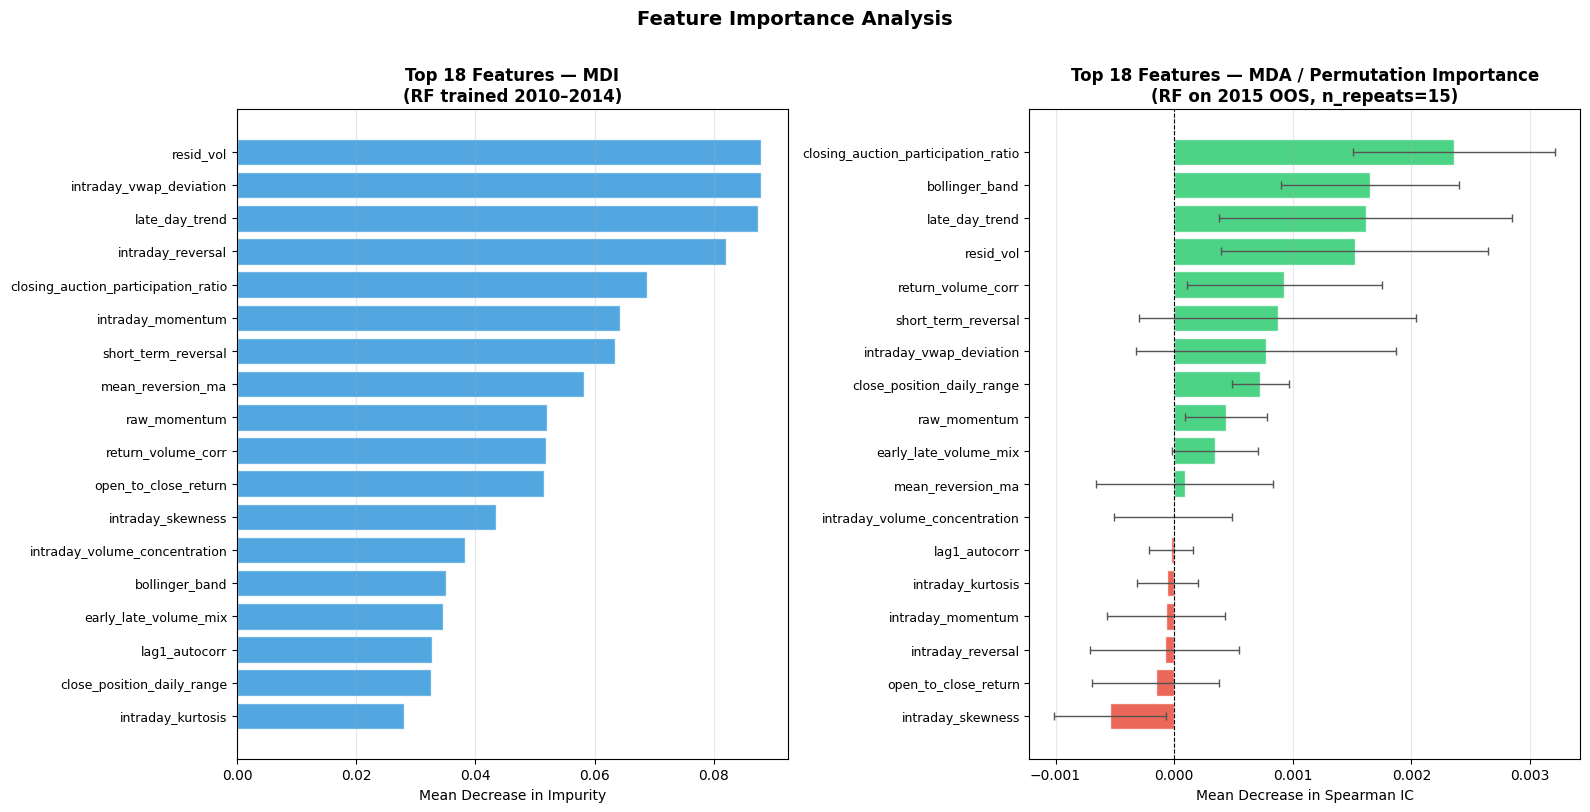


Top 5 MDI features: ['resid_vol', 'intraday_vwap_deviation', 'late_day_trend', 'intraday_reversal', 'closing_auction_participation_ratio']
Top 5 MDA features: ['closing_auction_participation_ratio', 'bollinger_band', 'late_day_trend', 'resid_vol', 'return_volume_corr']


In [43]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE — MDI (RF built-in) + MDA (permutation, 2015 OOS)
# ══════════════════════════════════════════════════════════════════════════
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

TOP_N = 20

# ── MDI — Random Forest trained on 2010–2014 ──────────────────────────────
mdi = pd.Series(rf_2015.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ── MDA — permutation importance on 2015 OOS ──────────────────────────────
def spearman_ic_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

scorer = make_scorer(spearman_ic_scorer, greater_is_better=True)
print("Computing MDA permutation importance on 2015 OOS (n_repeats=15)...")
perm = permutation_importance(
    rf_2015, df_2015_norm[feature_cols].values, y_2015,
    n_repeats=15, random_state=42, n_jobs=-1, scoring=scorer,
)
mda = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
mda_std = pd.Series(perm.importances_std, index=feature_cols)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# MDI
top_mdi = mdi.head(TOP_N)
n_mdi = len(top_mdi)
colors_mdi = ["#3498db" if v > 0 else "#e74c3c" for v in top_mdi.values[::-1]]
axes[0].barh(range(n_mdi), top_mdi.values[::-1], color=colors_mdi, alpha=0.85, edgecolor="white")
axes[0].set_yticks(range(n_mdi))
axes[0].set_yticklabels(top_mdi.index[::-1], fontsize=9)
axes[0].set_title(f"Top {n_mdi} Features — MDI\n(RF trained 2010–2014)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity", fontsize=10)
axes[0].grid(True, axis="x", alpha=0.3)

# MDA
top_mda = mda.head(TOP_N)
n_mda = len(top_mda)
top_mda_std = mda_std.loc[top_mda.index]
colors_mda = ["#2ecc71" if v > 0 else "#e74c3c" for v in top_mda.values[::-1]]
axes[1].barh(range(n_mda), top_mda.values[::-1], xerr=top_mda_std.values[::-1],
             color=colors_mda, alpha=0.85, edgecolor="white",
             error_kw={"ecolor": "#555", "capsize": 3, "linewidth": 1})
axes[1].set_yticks(range(n_mda))
axes[1].set_yticklabels(top_mda.index[::-1], fontsize=9)
axes[1].set_title(f"Top {n_mda} Features — MDA / Permutation Importance\n(RF on 2015 OOS, n_repeats=15)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mean Decrease in Spearman IC", fontsize=10)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].grid(True, axis="x", alpha=0.3)

plt.suptitle("Feature Importance Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print(f"\nTop 5 MDI features: {list(mdi.head(5).index)}")
print(f"Top 5 MDA features: {list(mda.head(5).index)}")

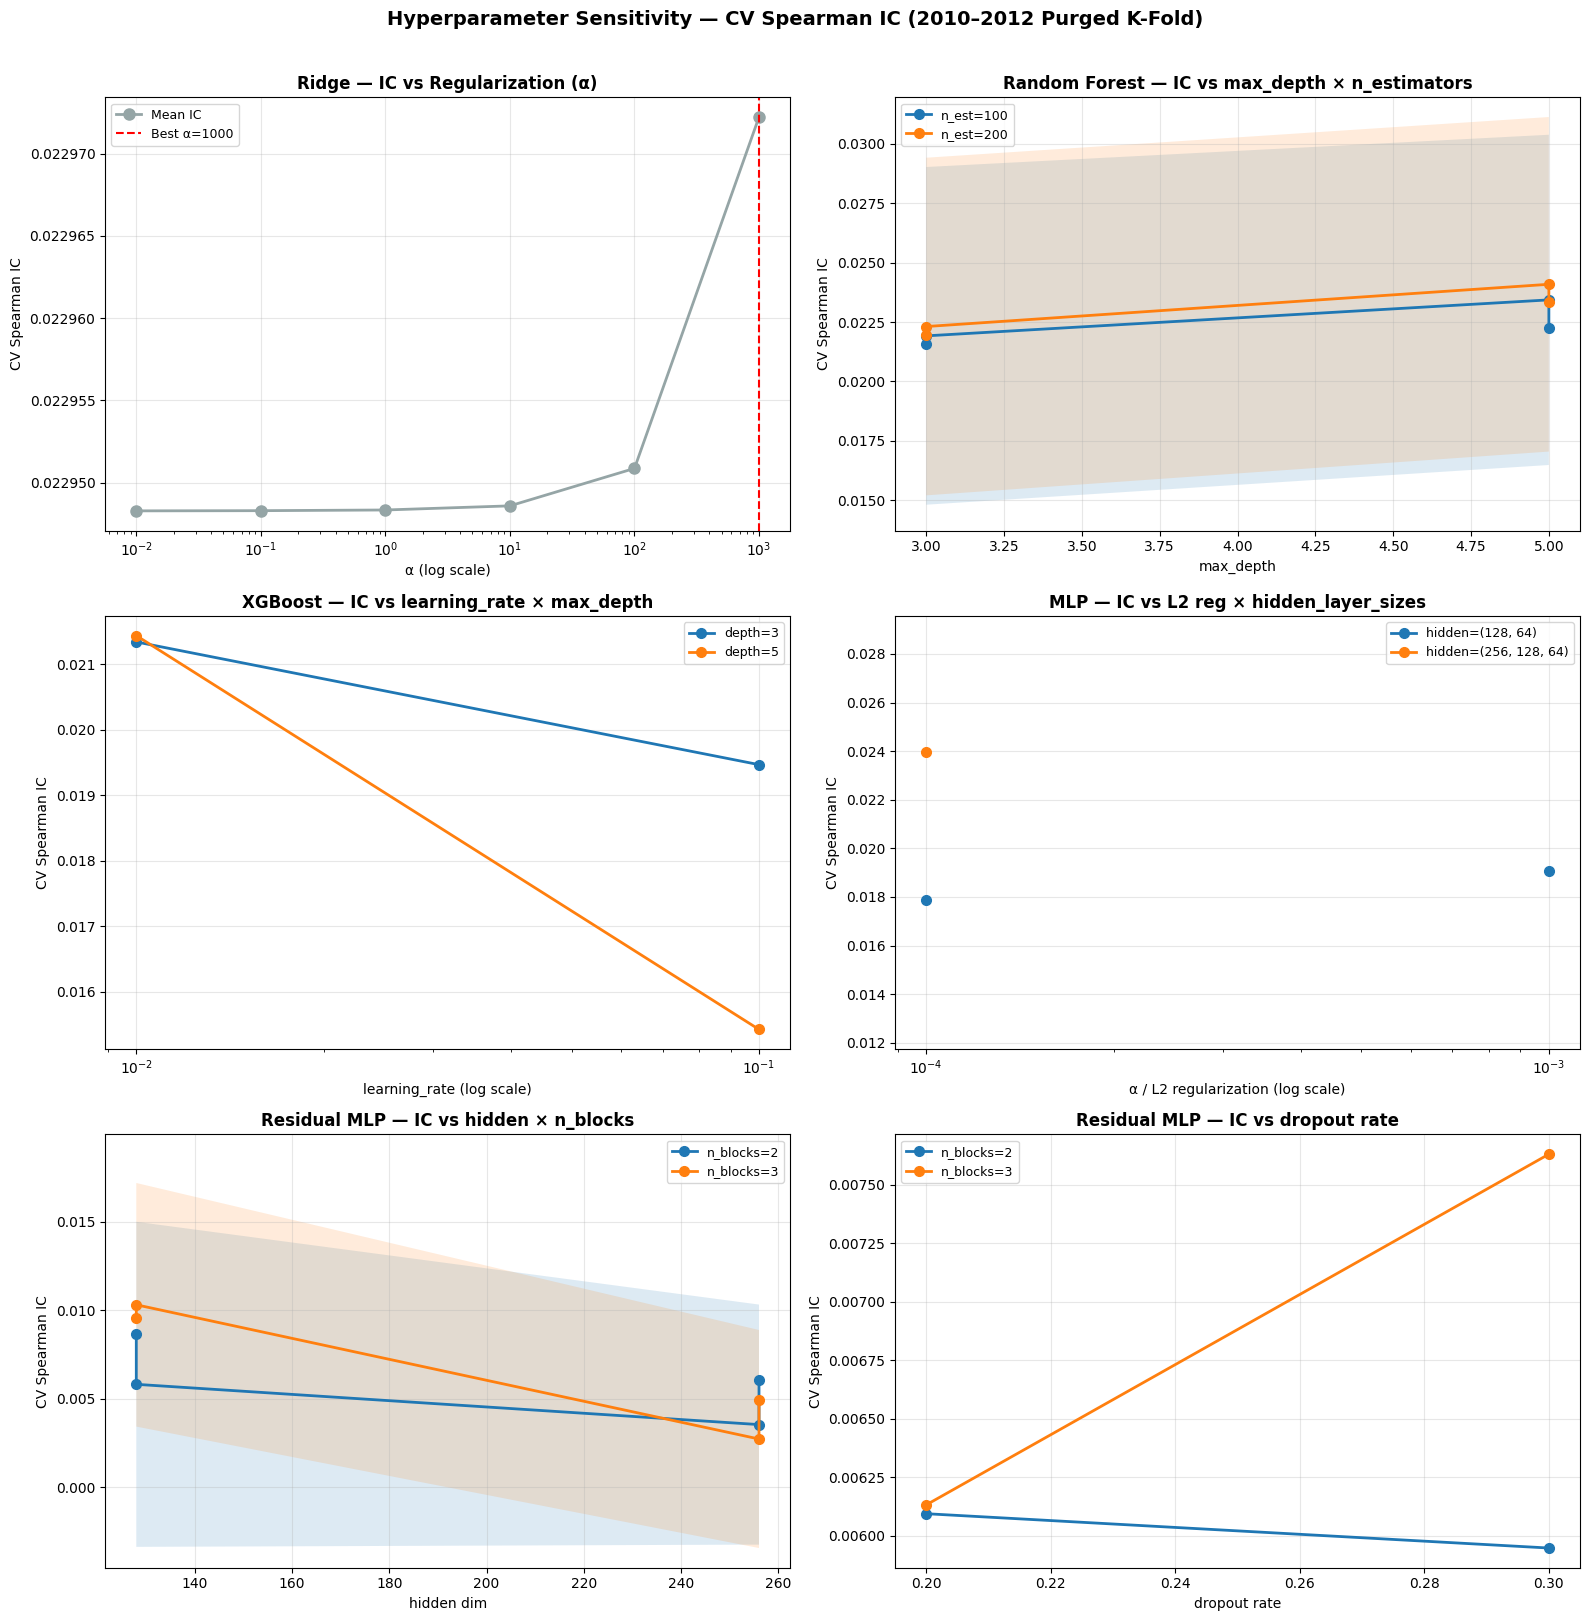

In [44]:
# ══════════════════════════════════════════════════════════════════════════
# HP SENSITIVITY CURVES — Cross-validated IC vs hyperparameters (all 5 models)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

# ── 1. Ridge: IC vs alpha ─────────────────────────────────────────────────
ax = axes[0]
ax.semilogx(hp_df["alpha"], hp_df["mean_SpearmanIC"], "o-", color="#95a5a6",
            linewidth=2, markersize=8, label="Mean IC")
best_alpha_idx = hp_df["mean_SpearmanIC"].idxmax()
ax.axvline(hp_df.loc[best_alpha_idx, "alpha"], color="red", linestyle="--", linewidth=1.5,
           label=f'Best α={hp_df.loc[best_alpha_idx, "alpha"]:.0f}')
ax.set_xlabel("α (log scale)", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("Ridge — IC vs Regularization (α)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 2. RF: IC vs max_depth, grouped by n_estimators ──────────────────────
ax = axes[1]
for n_est in sorted(rf_hp_df["n_estimators"].unique()):
    sub = rf_hp_df[rf_hp_df["n_estimators"] == n_est].sort_values("max_depth")
    ax.plot(sub["max_depth"], sub["mean_IC"], "o-", linewidth=2, markersize=7,
            label=f"n_est={n_est}")
    ax.fill_between(sub["max_depth"],
                    sub["mean_IC"] - sub["std_IC"],
                    sub["mean_IC"] + sub["std_IC"], alpha=0.15)
ax.set_xlabel("max_depth", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("Random Forest — IC vs max_depth × n_estimators", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 3. XGB: IC vs learning_rate, grouped by max_depth ────────────────────
ax = axes[2]
for d in sorted(xgb_hp_df["max_depth"].unique()):
    sub = xgb_hp_df[xgb_hp_df["max_depth"] == d].groupby("learning_rate")["mean_IC"].mean().reset_index()
    ax.semilogx(sub["learning_rate"], sub["mean_IC"], "o-", linewidth=2, markersize=7,
                label=f"depth={d}")
ax.set_xlabel("learning_rate (log scale)", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("XGBoost — IC vs learning_rate × max_depth", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 4. MLP: IC vs alpha (L2 reg), grouped by hidden_layer_sizes ──────────
ax = axes[3]
for h in sorted(mlp_hp_df["hidden_layer_sizes"].unique()):
    sub = mlp_hp_df[mlp_hp_df["hidden_layer_sizes"] == h].sort_values("alpha")
    ax.semilogx(sub["alpha"], sub["mean_IC"], "o-", linewidth=2, markersize=7, label=f"hidden={h}")
    ax.fill_between(sub["alpha"],
                    sub["mean_IC"] - sub["std_IC"],
                    sub["mean_IC"] + sub["std_IC"], alpha=0.15)
ax.set_xlabel("α / L2 regularization (log scale)", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("MLP — IC vs L2 reg × hidden_layer_sizes", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 5. ResidMLP: IC vs hidden, grouped by n_blocks ───────────────────────
ax = axes[4]
for nb_ in sorted(resmlp_hp_df["n_blocks"].unique()):
    sub = resmlp_hp_df[resmlp_hp_df["n_blocks"] == nb_].sort_values("hidden")
    ax.plot(sub["hidden"], sub["mean_IC"], "o-", linewidth=2, markersize=7, label=f"n_blocks={nb_}")
    ax.fill_between(sub["hidden"],
                    sub["mean_IC"] - sub["std_IC"],
                    sub["mean_IC"] + sub["std_IC"], alpha=0.15)
ax.set_xlabel("hidden dim", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("Residual MLP — IC vs hidden × n_blocks", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 6. ResidMLP: IC vs dropout ────────────────────────────────────────────
ax = axes[5]
for nb_ in sorted(resmlp_hp_df["n_blocks"].unique()):
    sub = resmlp_hp_df[resmlp_hp_df["n_blocks"] == nb_].groupby("dropout")["mean_IC"].mean().reset_index()
    ax.plot(sub["dropout"], sub["mean_IC"], "o-", linewidth=2, markersize=7, label=f"n_blocks={nb_}")
ax.set_xlabel("dropout rate", fontsize=10)
ax.set_ylabel("CV Spearman IC", fontsize=10)
ax.set_title("Residual MLP — IC vs dropout rate", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Hyperparameter Sensitivity — CV Spearman IC (2010–2012 Purged K-Fold)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

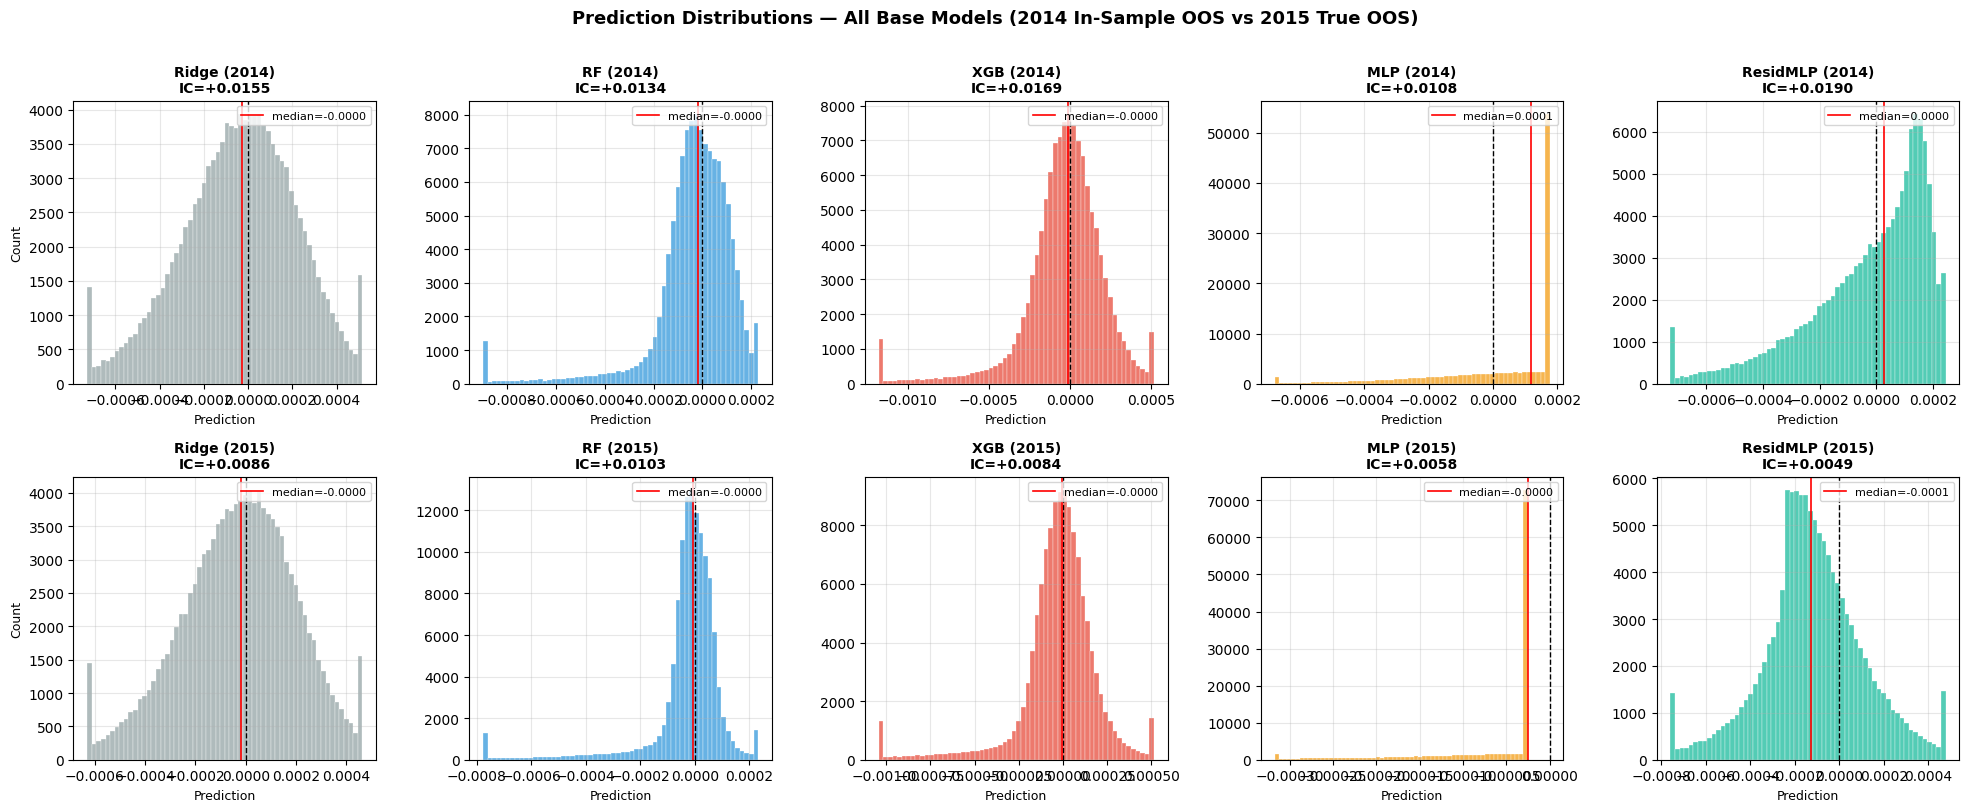

In [45]:
# ══════════════════════════════════════════════════════════════════════════
# PREDICTION DISTRIBUTIONS — Histograms for 2014 and 2015
# ══════════════════════════════════════════════════════════════════════════
BASE_MODELS = ["Ridge", "RF", "XGB", "MLP", "ResidMLP"]

fig, axes = plt.subplots(2, len(BASE_MODELS), figsize=(20, 8), sharey=False)

for col_i, model in enumerate(BASE_MODELS):
    for row_i, (year, preds_dict, y_true) in enumerate([
        ("2014", preds_2014, y_2014),
        ("2015", preds_2015, y_2015),
    ]):
        ax = axes[row_i, col_i]
        pred = preds_dict[model]

        # Clip extreme outliers for visual clarity
        lo, hi = np.percentile(pred, 1), np.percentile(pred, 99)
        pred_c = np.clip(pred, lo, hi)

        ax.hist(pred_c, bins=60, color=PALETTE[model], alpha=0.75, edgecolor="white", linewidth=0.3)
        ax.axvline(0, color="black", linewidth=1, linestyle="--")
        ax.axvline(np.median(pred), color="red", linewidth=1.2, linestyle="-", label=f"median={np.median(pred):.4f}")

        # Annotate IC
        ic = spearmanr(y_true, preds_dict[model]).correlation
        ax.set_title(f"{model} ({year})\nIC={ic:+.4f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Prediction", fontsize=9)
        ax.set_ylabel("Count" if col_i == 0 else "", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

plt.suptitle("Prediction Distributions — All Base Models (2014 In-Sample OOS vs 2015 True OOS)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

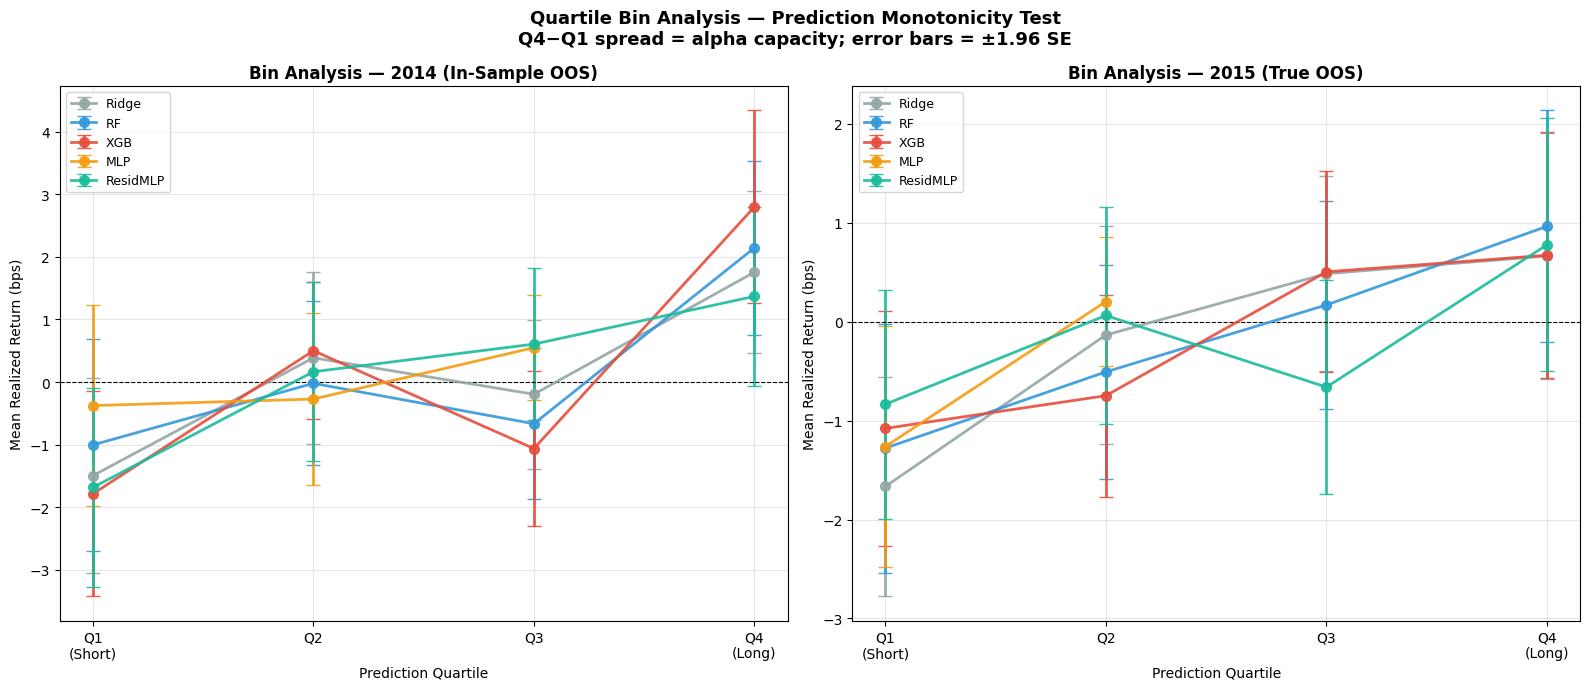

Q4−Q1 Spread (bps):

  2014:
    Ridge       : +3.25 bps
    RF          : +3.15 bps
    XGB         : +4.59 bps
    ResidMLP    : +3.05 bps

  2015:
    Ridge       : +2.33 bps
    RF          : +2.24 bps
    XGB         : +1.75 bps
    ResidMLP    : +1.61 bps


In [46]:
# ══════════════════════════════════════════════════════════════════════════
# BIN ANALYSIS — Mean realized return per prediction quartile (2014 & 2015)
# Shows monotonicity: Q1 (short) → Q4 (long) vs actual next-day return
# ══════════════════════════════════════════════════════════════════════════
def bin_analysis(y_true, preds_dict, dates, n_bins=4, label=""):
    """Per-date quartile binning: assign each stock to quartile, compute mean realized return."""
    rows = []
    date_arr = pd.DatetimeIndex(dates)
    for d in sorted(date_arr.unique()):
        m = np.asarray(date_arr == d)
        yt = y_true[m]
        if m.sum() < n_bins * 5:
            continue
        for model, preds in preds_dict.items():
            pp = preds[m]
            # Assign to quartile bins (1=lowest pred, 4=highest pred)
            qtiles = pd.qcut(pp, n_bins, labels=False, duplicates="drop")
            for q in range(n_bins):
                qm = qtiles == q
                if qm.sum() > 0:
                    rows.append({"model": model, "date": d, "bin": q + 1,
                                 "mean_return": yt[qm].mean()})
    df = pd.DataFrame(rows)
    return df.groupby(["model", "bin"])["mean_return"].agg(["mean", "sem"]).reset_index()


# ── Compute ───────────────────────────────────────────────────────────────
bins_2014 = bin_analysis(y_2014, {k: preds_2014[k] for k in BASE_MODELS}, dates_2014, label="2014")
bins_2015 = bin_analysis(y_2015, {k: preds_2015[k] for k in BASE_MODELS}, dates_2015, label="2015")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
x = np.arange(1, 5)   # bins 1–4

for ax, (bins_df, year) in zip(axes, [(bins_2014, "2014 (In-Sample OOS)"),
                                       (bins_2015, "2015 (True OOS)")]):
    for model in BASE_MODELS:
        sub = bins_df[bins_df["model"] == model].sort_values("bin")
        ax.errorbar(sub["bin"], sub["mean"] * 1e4,   # scale to bps
                    yerr=sub["sem"] * 1e4 * 1.96,
                    marker="o", linewidth=2, markersize=7, capsize=5,
                    color=PALETTE[model], label=model, alpha=0.9)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Q1\n(Short)", "Q2", "Q3", "Q4\n(Long)"], fontsize=10)
    ax.set_xlabel("Prediction Quartile", fontsize=10)
    ax.set_ylabel("Mean Realized Return (bps)", fontsize=10)
    ax.set_title(f"Bin Analysis — {year}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle("Quartile Bin Analysis — Prediction Monotonicity Test\n"
             "Q4−Q1 spread = alpha capacity; error bars = ±1.96 SE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Spread summary ─────────────────────────────────────────────────────────
print("Q4−Q1 Spread (bps):")
for year, bins_df in [("2014", bins_2014), ("2015", bins_2015)]:
    print(f"\n  {year}:")
    for model in BASE_MODELS:
        sub = bins_df[bins_df["model"] == model].set_index("bin")
        if 4 in sub.index and 1 in sub.index:
            spread = (sub.loc[4, "mean"] - sub.loc[1, "mean"]) * 1e4
            print(f"    {model:12s}: {spread:+.2f} bps")

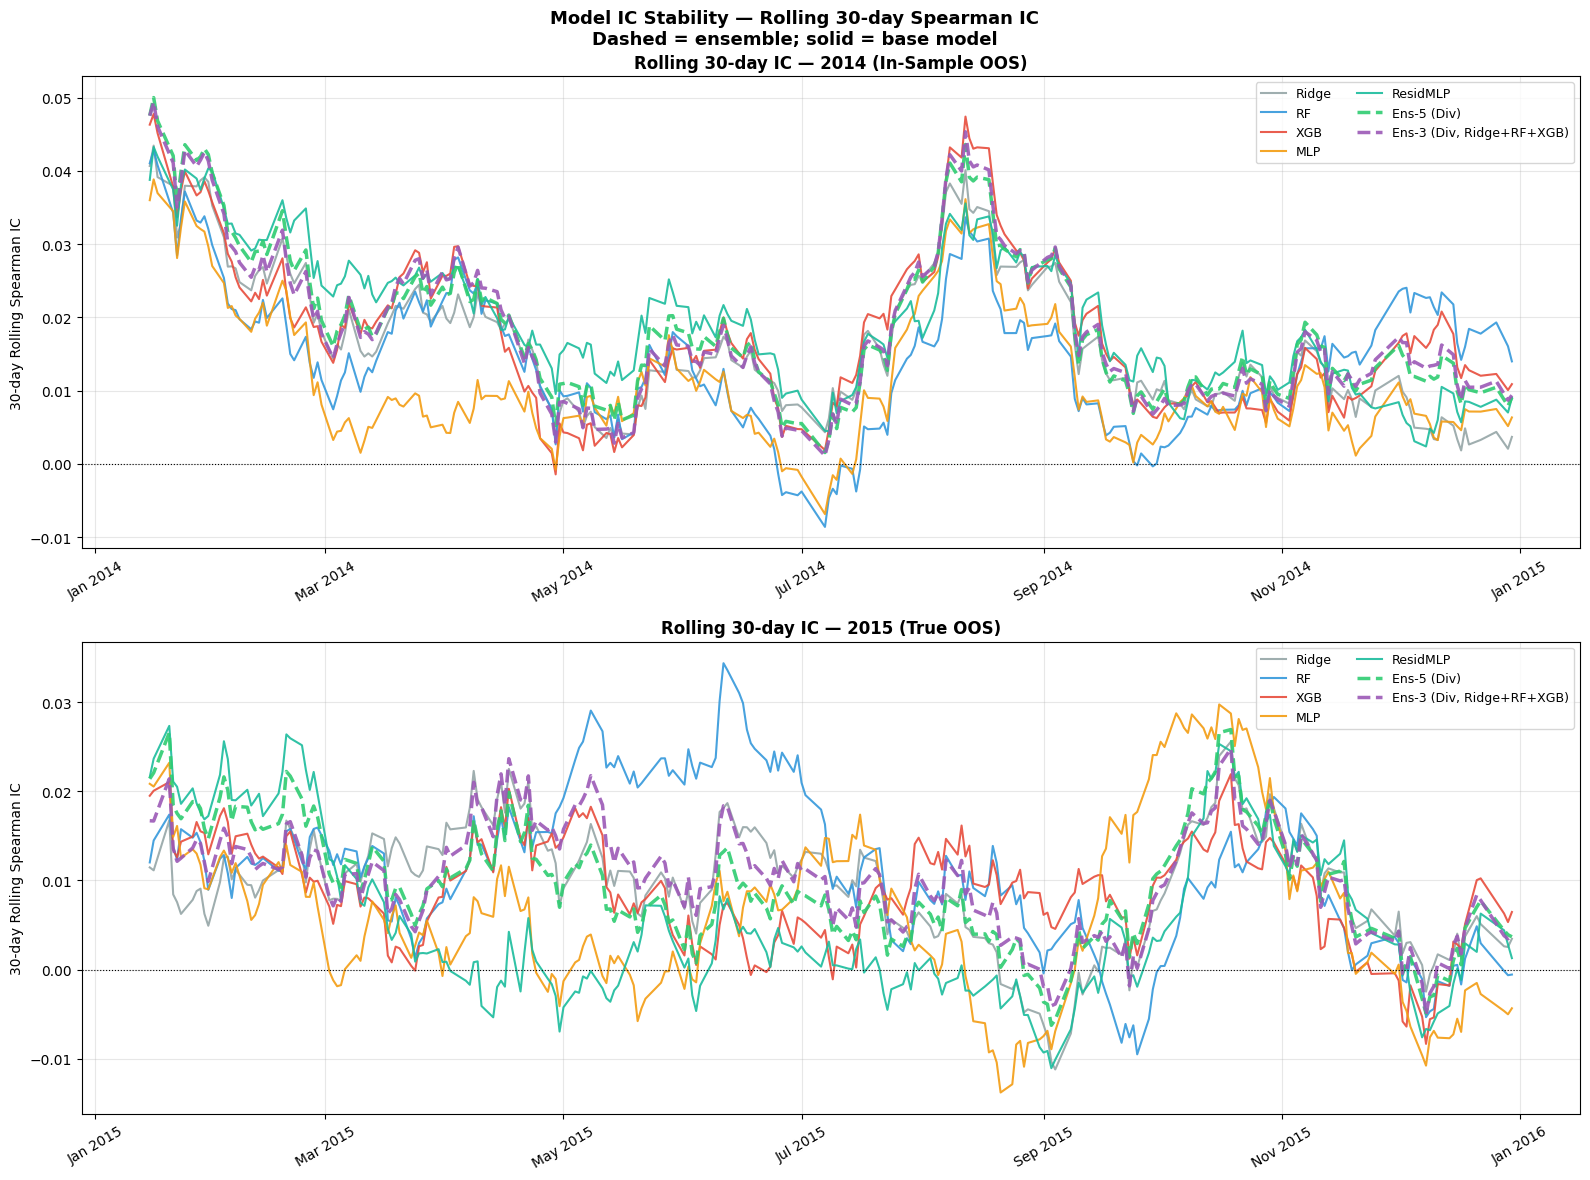

In [47]:
# ══════════════════════════════════════════════════════════════════════════
# ROLLING 30-DAY IC — Model stability over time (2014 and 2015)
# ══════════════════════════════════════════════════════════════════════════
ALL_MODELS = list(PALETTE.keys())   # includes ensembles

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for ax, (year, preds_dict, y_true, dates) in zip(axes, [
    ("2014 (In-Sample OOS)", preds_2014, y_2014, dates_2014),
    ("2015 (True OOS)",      all_preds_2015, y_2015, dates_2015),
]):
    for model in ALL_MODELS:
        if model not in preds_dict:
            continue
        ic_series = daily_ic(y_true, preds_dict[model], dates)
        roll_ic = ic_series.rolling(30, min_periods=10).mean()
        ls = "--" if "Ens" in model else "-"
        lw = 2.5 if "Ens" in model else 1.5
        ax.plot(roll_ic.index, roll_ic.values,
                label=model, color=PALETTE[model],
                linewidth=lw, linestyle=ls, alpha=0.9)

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_ylabel("30-day Rolling Spearman IC", fontsize=10)
    ax.set_title(f"Rolling 30-day IC — {year}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right", ncol=2)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Model IC Stability — Rolling 30-day Spearman IC\n"
             "Dashed = ensemble; solid = base model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Building per-date prediction dicts...
Computing drift for 2014 (up to 60 dates)...
Computing drift for 2015 (up to 60 dates)...


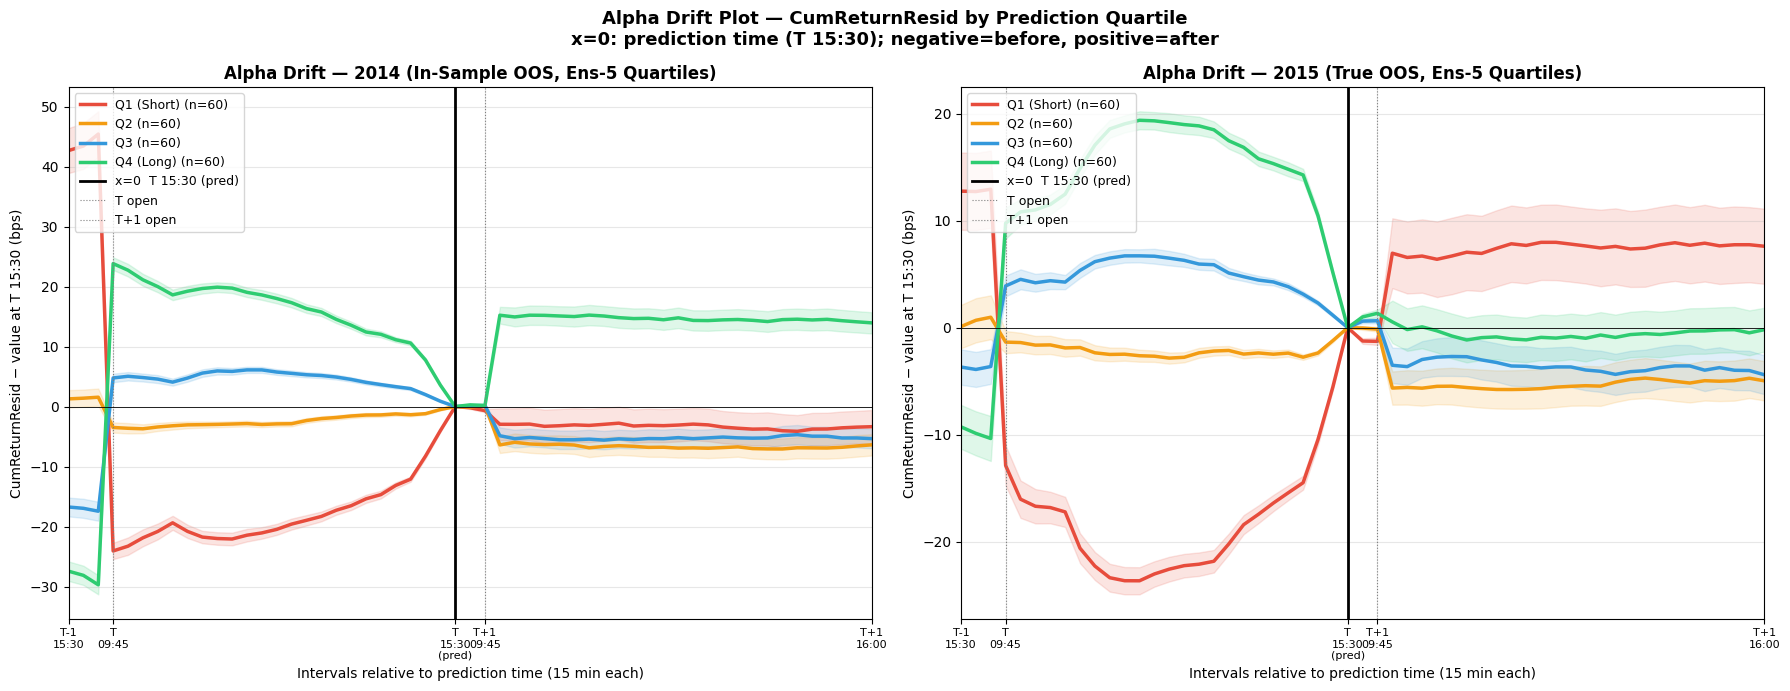


✓ Drift plots complete.


In [50]:
# ══════════════════════════════════════════════════════════════════════════
# ALPHA DRIFT PLOT — Intraday CumReturnResid conditioned on prediction quartile
#
# For each date T (prediction at 15:30):
#   - Load raw intraday CSVs for T-1, T, T+1
#   - Trim to 26 bars back (T-1 15:30 → x=-26) through T+1 16:00 (x=+28)
#   - Normalize to 0 at T 15:30 (x=0)
#   - Bin stocks by Ens-5 quartile, average paths ± 1 SE
#
# X-axis: interval index relative to T 15:30 (negative=before, positive=after)
# Vertical line at x=0 marks prediction time
# ══════════════════════════════════════════════════════════════════════════
from pathlib import Path

def load_drift_data(intraday_dir: Path, trading_dates: list, pred_by_date: dict,
                    n_bins: int = 4, max_dates: int = 60, seed: int = 42):
    rng = np.random.default_rng(seed)
    files_map = {f.stem: f for f in sorted(intraday_dir.glob("*.csv"))}
    file_keys  = sorted(files_map.keys())

    date_strs = [d.strftime("%Y%m%d") for d in trading_dates if d.strftime("%Y%m%d") in files_map]
    if len(date_strs) > max_dates:
        date_strs = list(rng.choice(date_strs, size=max_dates, replace=False))
        date_strs = sorted(date_strs)

    # Full 3-day window: 78 bars (26 per day)
    # T 15:30 = bar 49 (T starts at bar 26; 15:30 is the 24th bar of T → bar 26+23=49)
    # Trim: start at bar 23 (T-1 15:30, x=-26) → end at bar 77 (T+1 16:00, x=+28)
    FULL_BARS = 78
    REF_BAR   = 49   # T 15:30 in the 78-bar window
    TRIM_START = 23  # T-1 15:30 → x = 23 - 49 = -26
    # Relative indices: x = bar_idx - REF_BAR  (x=0 at prediction time)

    bin_paths = {q: [] for q in range(n_bins)}

    for date_str in date_strs:
        if date_str not in pred_by_date:
            continue
        idx_key = file_keys.index(date_str)
        if idx_key == 0 or idx_key >= len(file_keys) - 1:
            continue

        try:
            dfs = []
            for day_idx, key in enumerate([file_keys[idx_key - 1], date_str, file_keys[idx_key + 1]]):
                df_day = pd.read_csv(files_map[key], usecols=["Time", "Id", "CumReturnResid"])
                df_day = df_day.sort_values("Time")
                time_order = dict(zip(sorted(df_day["Time"].unique()), range(26)))
                df_day["bar"] = df_day["Time"].map(time_order) + day_idx * 26
                dfs.append(df_day)
            df3 = pd.concat(dfs, ignore_index=True)
        except Exception:
            continue

        pivot = df3.pivot_table(index="bar", columns="Id", values="CumReturnResid", aggfunc="first")
        if pivot.shape[0] != FULL_BARS or REF_BAR not in pivot.index:
            continue

        preds_t = pred_by_date[date_str]
        common_ids = pivot.columns.intersection(preds_t.index)
        if len(common_ids) < 20:
            continue

        pivot = pivot[common_ids]
        preds_aligned = preds_t.loc[common_ids]

        # Normalize to 0 at prediction time (T 15:30)
        ref_vals = pivot.loc[REF_BAR]
        path_rel = pivot.subtract(ref_vals, axis=1)

        # Trim to [TRIM_START, 77] and convert to relative x-axis
        path_trim = path_rel.loc[TRIM_START:]   # bars 23..77 → x = -26..+28

        qtiles = pd.qcut(preds_aligned, n_bins, labels=False, duplicates="drop")
        for q in range(n_bins):
            ids_q = qtiles[qtiles == q].index
            if len(ids_q) < 5:
                continue
            bin_paths[q].append(path_trim[ids_q].mean(axis=1).values)

    return bin_paths, REF_BAR, TRIM_START


def plot_drift(bin_paths, ref_bar, trim_start, title, ax, n_bins=4):
    bin_colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
    bin_labels = ["Q1 (Short)", "Q2", "Q3", "Q4 (Long)"]

    n_pts = 78 - trim_start          # number of trimmed bars (23..77 = 55 pts)
    x = np.arange(trim_start, 78) - ref_bar   # relative indices: -26 to +28

    for q in range(n_bins):
        paths = np.array(bin_paths[q])
        if len(paths) < 3:
            continue
        mean = paths.mean(axis=0) * 1e4        # bps
        se   = paths.std(axis=0) / np.sqrt(len(paths)) * 1e4
        ax.plot(x, mean, color=bin_colors[q], linewidth=2.5,
                label=f"{bin_labels[q]} (n={len(paths)})")
        ax.fill_between(x, mean - se, mean + se, color=bin_colors[q], alpha=0.15)

    ax.axvline(0,  color="black", linewidth=2.0, linestyle="-",  label="x=0  T 15:30 (pred)")
    ax.axvline(-ref_bar + 26, color="gray",  linewidth=0.8, linestyle=":", label="T open")   # T 09:45 = bar 26 → x=26-49=-23
    ax.axvline(2,  color="gray",  linewidth=0.8, linestyle=":", label="T+1 open")             # T+1 09:45 = bar 52 → x=52-49=+3
    ax.axhline(0,  color="black", linewidth=0.6)

    # Mark key x positions
    key_xs   = [-26, -23, 0, 2, x[-1]]
    key_lbls = ["T-1\n15:30", "T\n09:45", "T\n15:30\n(pred)", "T+1\n09:45", "T+1\n16:00"]
    ax.set_xticks(key_xs)
    ax.set_xticklabels(key_lbls, fontsize=8)

    ax.set_xlabel("Intervals relative to prediction time (15 min each)", fontsize=10)
    ax.set_ylabel("CumReturnResid − value at T 15:30 (bps)", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x[0], x[-1])


# ── Build pred_by_date dicts ──────────────────────────────────────────────
print("Building per-date prediction dicts...")

def build_pred_by_date(preds_arr, norm_df):
    pbd = {}
    date_idx = pd.DatetimeIndex(norm_df.index)
    id_col = norm_df["Id"].values if "Id" in norm_df.columns else np.arange(len(norm_df)).astype(str)
    for d in date_idx.unique():
        m = date_idx == d
        pbd[d.strftime("%Y%m%d")] = pd.Series(preds_arr[m], index=id_col[m])
    return pbd

pred_by_date_2014 = build_pred_by_date(preds_2014["Ens-5 (Div)"],       df_test_norm)
pred_by_date_2015 = build_pred_by_date(all_preds_2015["Ens-5 (Div)"],   df_2015_norm)

INTRADAY_2014 = ROOT_DIR / "raw_data" / "data_intraday"
INTRADAY_2015 = ROOT_DIR / "oos_data"  / "intraday_data"

trading_dates_2014 = sorted(df_test_norm.index.unique())
trading_dates_2015 = sorted(df_2015_norm.index.unique())

print("Computing drift for 2014 (up to 60 dates)...")
bin_paths_2014, ref_bar, trim_start = load_drift_data(
    INTRADAY_2014, trading_dates_2014, pred_by_date_2014, max_dates=60)

print("Computing drift for 2015 (up to 60 dates)...")
bin_paths_2015, _, _                = load_drift_data(
    INTRADAY_2015, trading_dates_2015, pred_by_date_2015, max_dates=60)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_drift(bin_paths_2014, ref_bar, trim_start,
           "Alpha Drift — 2014 (In-Sample OOS, Ens-5 Quartiles)", axes[0])
plot_drift(bin_paths_2015, ref_bar, trim_start,
           "Alpha Drift — 2015 (True OOS, Ens-5 Quartiles)", axes[1])

plt.suptitle("Alpha Drift Plot — CumReturnResid by Prediction Quartile\n"
             "x=0: prediction time (T 15:30); negative=before, positive=after",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n✓ Drift plots complete.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE TIME SERIES — Monthly aggregates across all 5 years (2010–2015)
# Per feature: 5 lines — mean, 1st/99th percentile, min, max
# Uses RAW (pre-normalization) features so values are interpretable
# Saves figure → submission_files/figures/monthly_feature_distribution_all_features.png
# ══════════════════════════════════════════════════════════════════════════
from src.config import FEATURE_DATA_DIR
from pathlib import Path

feat_dir   = FEATURE_DATA_DIR / "feature_together"
FIGURES_DIR = Path(__file__).resolve().parent / "figures" if "__file__" in dir() else \
              Path.cwd().parent / "submission_files" / "figures"
# Fallback: resolve relative to project root
FIGURES_DIR = Path.cwd().parent / "submission_files" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Loading raw feature data for all 5 years...")
df_raw_all = pd.concat([
    pd.read_parquet(feat_dir / "features_raw_train.parquet"),   # 2010–2013
    pd.read_parquet(feat_dir / "features_raw_test.parquet"),    # 2014
    pd.read_parquet(feat_dir / "features_raw_oos2015.parquet"), # 2015
]).sort_index()

feat_ts_cols = [c for c in df_raw_all.columns if c not in {"Id", "target_variable"}]
print(f"  {len(feat_ts_cols)} features, {df_raw_all.index.min().date()} → {df_raw_all.index.max().date()}")

# Monthly aggregation
df_raw_all.index = pd.DatetimeIndex(df_raw_all.index)
monthly = df_raw_all[feat_ts_cols].resample("ME").agg(
    ["mean",
     lambda x: x.quantile(0.01),
     lambda x: x.quantile(0.99),
     "min", "max"]
)
monthly.columns = ["_".join(c) if isinstance(c, tuple) else c for c in monthly.columns]
monthly.columns = [
    c.replace("<lambda_0>", "p01").replace("<lambda_1>", "p99")
    for c in monthly.columns
]

# ── Plot ──────────────────────────────────────────────────────────────────
n_feats = len(feat_ts_cols)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for ax_i, feat in enumerate(feat_ts_cols):
    ax = axes[ax_i]
    mn   = monthly[f"{feat}_mean"]
    p01  = monthly[f"{feat}_p01"]
    p99  = monthly[f"{feat}_p99"]
    fmin = monthly[f"{feat}_min"]
    fmax = monthly[f"{feat}_max"]

    ax.plot(mn.index,   mn.values,   color="#2c3e50", linewidth=2.0, label="Mean")
    ax.plot(p01.index,  p01.values,  color="#3498db", linewidth=1.0, linestyle="--", label="1st pct")
    ax.plot(p99.index,  p99.values,  color="#e74c3c", linewidth=1.0, linestyle="--", label="99th pct")
    ax.fill_between(fmin.index, fmin.values, fmax.values, color="#bdc3c7", alpha=0.3, label="Min–Max")

    ax.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2014-12-31"),
               alpha=0.08, color="#f39c12", label="2014 OOS")
    ax.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2015-12-31"),
               alpha=0.08, color="#e74c3c", label="2015 OOS")

    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_ylabel("Feature value", fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    if ax_i == 0:
        ax.legend(fontsize=7, loc="upper right", ncol=2)

for ax_i in range(n_feats, len(axes)):
    axes[ax_i].set_visible(False)

plt.suptitle("Feature Time Series — Monthly Aggregates (2010–2015)\n"
             "Mean (dark), 1st/99th pct (dashed), Min/Max shaded; orange=2014 OOS, red=2015 OOS",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

# Save for white paper
_fig_path = FIGURES_DIR / "monthly_feature_distribution_all_features.png"
fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
print(f"✓ Saved → {_fig_path}")
plt.show()
print("✓ Feature time series complete.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE BIN PLOTS — Top features binned vs mean target variable
# Saves → submission_files/figures/top_feature_bin_plots_train_4bins.png
# ══════════════════════════════════════════════════════════════════════════
df_raw_train   = pd.read_parquet(feat_dir / "features_raw_train.parquet")
target_col_raw = "target_variable"
top8_features  = list(mdi.head(8).index)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax_i, feat in enumerate(top8_features):
    ax = axes[ax_i]
    sub = df_raw_train[[feat, target_col_raw]].dropna()

    try:
        sub = sub.copy()
        sub["bin"] = pd.qcut(sub[feat], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
    except Exception:
        ax.set_visible(False)
        continue

    grouped = sub.groupby("bin", observed=True)[target_col_raw].agg(["mean", "sem"])
    colors   = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
    ax.bar(grouped.index, grouped["mean"] * 1e4,
           yerr=grouped["sem"] * 1e4 * 1.96,
           color=colors, alpha=0.8, edgecolor="white",
           capsize=4, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{feat}\n(MDI rank #{list(mdi.index).index(feat)+1})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Feature Quartile", fontsize=9)
    ax.set_ylabel("Mean Target (bps)" if ax_i % 4 == 0 else "", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    ic = spearmanr(sub[feat], sub[target_col_raw]).correlation
    ax.text(0.05, 0.95, f"IC={ic:+.4f}", transform=ax.transAxes,
            fontsize=9, va="top", color="#2c3e50",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.suptitle("Feature Bin Plots — Top 8 Features (by MDI) vs Target Variable\n"
             "Training data 2010–2013; Q4−Q1 spread shows feature signal; ±1.96 SE",
             fontsize=13, fontweight="bold")
plt.tight_layout()

_fig_path2 = FIGURES_DIR / "top_feature_bin_plots_train_4bins.png"
fig.savefig(_fig_path2, dpi=150, bbox_inches="tight")
print(f"✓ Saved → {_fig_path2}")
plt.show()
print("✓ Feature bin plots complete.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# WEIGHTED R² — Using resid_vol as proxy for estVol (weights = 1/resid_vol)
# PDF §3 benchmark: √MDV63 weights; §5.2 white paper: 1/estVol weights
# ══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import r2_score

def weighted_r2(y_true, y_pred, weights):
    """Weighted R² per sklearn convention: 1 - SS_res_w / SS_tot_w."""
    w = np.asarray(weights)
    w = w / w.sum()
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - np.average(y_true, weights=w)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

# ── Build weight arrays ────────────────────────────────────────────────────
# 1/estVol proxy: use resid_vol feature (pre-normalization, raw)
# Fall back to uniform if not available

if "resid_vol" in df_test_norm.columns:
    w2014_raw = df_test_norm["resid_vol"].values
    w2014_raw = np.where(w2014_raw > 0, 1.0 / w2014_raw, np.nan)
else:
    print("resid_vol not in df_test_norm — using uniform weights for 2014")
    w2014_raw = np.ones(len(y_2014))

if "resid_vol" in df_2015_norm.columns:
    w2015_raw = df_2015_norm["resid_vol"].values
    w2015_raw = np.where(w2015_raw > 0, 1.0 / w2015_raw, np.nan)
else:
    print("resid_vol not in df_2015_norm — using uniform weights for 2015")
    w2015_raw = np.ones(len(y_2015))

# Replace NaN weights with median
for w_arr in [w2014_raw, w2015_raw]:
    med = np.nanmedian(w_arr)
    w_arr[np.isnan(w_arr)] = med

# ── Compute weighted R² for all models ────────────────────────────────────
print(f"{'Model':40s}  {'Weighted R² 2014':>17s}  {'Weighted R² 2015':>17s}")
print("-" * 80)
rows_wt = []
for name in list(preds_2014.keys()):
    pred14 = preds_2014[name]
    pred15 = all_preds_2015.get(name)
    wr2_14 = weighted_r2(y_2014, pred14, w2014_raw)
    wr2_15 = weighted_r2(y_2015, pred15, w2015_raw) if pred15 is not None else float("nan")
    rows_wt.append({"Model": name, "Wtd R² 2014 (1/vol)": wr2_14, "Wtd R² 2015 (1/vol)": wr2_15})
    print(f"  {name:38s}  {wr2_14:+.6f}          {wr2_15:+.6f}")

df_wt_results = pd.DataFrame(rows_wt).set_index("Model")
print("\nWeighted R² Summary (weights = 1/resid_vol ≈ 1/estVol):")
display(df_wt_results.round(6))


Model                                      Weighted R² 2014   Weighted R² 2015
--------------------------------------------------------------------------------
  Ridge                                   +0.000147          -0.000389
  RF                                      +0.000158          +0.000200
  XGB                                     +0.000494          -0.000093
  MLP                                     +0.000185          -0.000018
  ResidMLP                                +0.000384          -0.000618
  Ens-5 (Div)                             +0.000361          -0.000040
  Ens-3 (Div, Ridge+RF+XGB)               +0.000342          +0.000005

Weighted R² Summary (weights = 1/resid_vol ≈ 1/estVol):


,Wtd R² 2014 (1/vol),Wtd R² 2015 (1/vol)
Model,,
Ridge,0.000147,-0.000389
RF,0.000158,0.000200
XGB,0.000494,-0.000093
MLP,0.000185,-0.000018
ResidMLP,0.000384,-0.000618
Ens-5 (Div),0.000361,-0.000040
"Ens-3 (Div, Ridge+RF+XGB)",0.000342,0.000005



Note: PDF §3 uses √MDV63 for grader benchmark; §5.2 uses 1/estVol for white paper reporting.
